# **OpenLCA resuls analysis**

#### **Setup Data Analyse**

**Open libraries**

In [114]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Open database**

In [115]:
# --- file locations, portable version ----------------------------------------
# This notebook finds its inputs BY NAME, not by folder path.
# Put the notebook and the CSV files together in one folder and it runs.
# The original Outputs/3_impact_assessment and Outputs/4_monte_carlo layout
# also still works, so nothing breaks in the project repository.
from pathlib import Path

_HERE = Path.cwd()

def _search_dirs():
    seen, out = set(), []
    def add(p):
        p = Path(p)
        try:
            key = str(p.resolve())
        except OSError:
            return
        if p.is_dir() and key not in seen:
            seen.add(key); out.append(p)
    add(_HERE)
    for base in [_HERE, *list(_HERE.parents)[:3]]:
        add(base / "Outputs" / "3_impact_assessment")
        add(base / "Outputs" / "4_monte_carlo")
        add(base / "Outputs")
        add(base)
    return out

DATA_DIRS = _search_dirs()

def find_data(name):
    """Path to <name>, searched by file name, nearest folder first."""
    for d in DATA_DIRS:
        p = d / name
        if p.is_file():
            return p
    hits = sorted(_HERE.rglob(name))          # last resort, search below the notebook
    if hits:
        return hits[0]
    return _HERE / name                        # not found: .exists() stays False

class _ByName:
    """Lets BASE / "file.csv" and MC / "file.csv" work without a fixed folder."""
    def __truediv__(self, name):
        return find_data(name)
    def __repr__(self):
        return f"<inputs resolved by name, starting at {_HERE}>"

BASE = MC = IA = _ByName()

FIGS = _HERE                                   # figures and tables are written beside the notebook

_need = ["impact_EF31.csv", "impact_ReCiPe_mid.csv", "impact_screening.csv",
         "impact_screening_ReCiPe_mid.csv", "impact_stage_contributions.csv"] + \
        [f"mc_raw_{k}.csv" for k in ["Sc1", "Sc2g", "Sc2s", "Sc3g", "Sc3s", "Sc4g", "Sc4s"]]
_miss = [n for n in _need if not find_data(n).is_file()]

print("notebook folder :", _HERE)
print("inputs found    :", len(_need) - len(_miss), "of", len(_need))
if _miss:
    print("MISSING         :", ", ".join(_miss))
else:
    print("all inputs present")


project root : C:\Claude\Projects\AR_DPP\LCA_Analysis
figures ->   : C:\Claude\Projects\AR_DPP\LCA_Analysis\LCA_Notebook\figures


In [116]:
BASE_FILES = {
    "EF 3.1":              BASE / "impact_EF31.csv",
    "ReCiPe midpoint (H)": BASE / "impact_ReCiPe_mid.csv",
    "ReCiPe endpoint (H,A)": BASE / "impact_ReCiPe_end.csv",
}

**Setup chart config**

In [117]:
# --- chart styling ----------------------------------------------------------
# Scenarios Sc1..Sc4 are an ORDERED progression (increasing circularity), so they
# get one hue from light to dark. That ordering survives a black-and-white print,
# which a four-colour palette would not.
SC_COLOR = {"sc1": "#b8d3ea", "sc2": "#6fa3d2", "sc3": "#2f6aa6", "sc4": "#16406b"}
SC_NAME  = {"sc1": "Sc1 landfill", "sc2": "Sc2 bulk WEEE",
            "sc3": "Sc3 guided dismantling", "sc4": "Sc4 guided + reuse"}
SCEN     = ["sc1", "sc2", "sc3", "sc4"]

# For things that are identities rather than an order (gross vs credit, EF vs
# ReCiPe, the three areas of protection). Colour-blind safe.
BLUE, AMBER, GREEN = "#0072B2", "#E69F00", "#009E73"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dcdcdc", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def save(fig, name):
    """Save a chart as PNG (for Word) and PDF (vector, for the final print)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"{name}.{ext}")
    print(f"saved: {name}.png / .pdf")


# --- shared helpers ----------------------------------------------------------
# The three categories the screening selects. Defined here so the charts stay
# focused and every part of the notebook names them the same way.
REPORTING = ["Resource use minerals and metals", "Climate change",
             "Eutrophication freshwater"]

def wrap(s, w=24):
    """Break a long category name onto several lines so panel titles don't
    collide with the neighbouring panel."""
    words, lines, cur = s.split(), [], ""
    for x in words:
        if len(cur) + len(x) + 1 > w and cur:
            lines.append(cur); cur = x
        else:
            cur = f"{cur} {x}".strip()
    lines.append(cur)
    return "\n".join(lines)

def sig(v, n=3):
    """n significant digits, keeping trailing zeros so bar labels line up."""
    import math
    if v == 0 or not np.isfinite(v):
        return "0"
    d = n - 1 - math.floor(math.log10(abs(v)))
    return f"{v:.{max(d, 0)}f}"

# **Impact EF3.1 (adapted)**

In [118]:
# --- load the EF3.1 impact table --------------------------------------------
# One row per impact category; columns are gross / saving / net per scenario,
# plus the unit. `category` is the natural index.
ef = pd.read_csv(BASE / "impact_EF31.csv")

UNIT = ef.set_index("category")["unit"]              # keep units aside
ef = ef.set_index("category").drop(columns="unit").astype(float)

print(f"{ef.shape[0]} categories x {ef.shape[1]} columns  <- {BASE / 'impact_EF31.csv'}")
ef.head(10)

25 categories x 10 columns  <- C:\Claude\Projects\AR_DPP\LCA_Analysis\Outputs\3_impact_assessment\impact_EF31.csv


,sc1,sc2_gross,sc2_saving,sc2_net,sc3_gross,sc3_saving,sc3_net,sc4_gross,sc4_saving,sc4_net
category,,,,,,,,,,
Acidification,0.573954,0.574141,0.056551,0.517590,0.574107,0.112018,0.462089,0.574111,0.163262,0.410849
Climate change,73.432586,73.479433,4.418978,69.060455,73.409331,8.162726,65.246605,73.410318,15.431529,57.978789
Climate change (biogenic),0.214481,0.214551,0.015206,0.199345,0.214576,0.025180,0.189396,0.214594,0.039154,0.175440
Climate change (fossil),72.993893,73.040596,4.348220,68.692376,72.970462,8.068483,64.901979,72.971422,15.310760,57.660662
Climate change (land use),0.224211,0.224287,0.055553,0.168734,0.224293,0.069063,0.155229,0.224302,0.081615,0.142687
Ecotoxicity freshwater,1451.953396,1452.164679,128.435253,1323.729426,1452.139627,413.323663,1038.815964,1452.136605,626.126218,826.010386
Ecotoxicity freshwater (inorganics),1433.539557,1433.746086,126.477826,1307.268260,1433.713989,410.360142,1023.353846,1433.711513,620.808990,812.902524
Ecotoxicity freshwater (organics),18.413839,18.418593,1.957427,16.461166,18.425639,2.963521,15.462118,18.425091,5.317229,13.107863
Eutrophication freshwater,0.115920,0.115935,0.006899,0.109036,0.115929,0.019143,0.096787,0.115937,0.029761,0.086176


#### Analysing most representatives categories

In [119]:
scr = pd.read_csv(BASE / "impact_screening.csv")

for c in ("in_reporting_set", "goal_pinned"):
    if scr[c].dtype == object:
        scr[c] = scr[c].astype(str).str.strip().str.lower() == "true"
scr = scr.sort_values("share_pct", ascending=False).reset_index(drop=True)

print(f"reporting set covers {scr.loc[scr.in_reporting_set, 'share_pct'].sum():.1f} % "
      f"of the weighted footprint")
scr

reporting set covers 85.7 % of the weighted footprint


,category,weighted_pe,share_pct,cum_pct,in_reporting_set,goal_pinned
0,Resource use minerals and metals,0.022237,72.452384,72.452384,True,True
1,Climate change,0.002047,6.671002,79.123386,True,True
2,Eutrophication freshwater,0.002020,6.581230,85.704616,True,False
3,Resource use fossils,0.001305,4.250810,89.955426,False,False
4,Acidification,0.000640,2.086411,92.041838,False,False
5,Ecotoxicity freshwater,0.000492,1.601445,93.643282,False,False
6,Particulate matter,0.000436,1.419454,95.062736,False,False
7,Human toxicity non-cancer,0.000354,1.153024,96.215761,False,False
8,Photochemical ozone formation (human health),0.000293,0.955340,97.171100,False,False
9,Water use,0.000285,0.930024,98.101124,False,False


saved: p2_01_screening_pareto.png / .pdf


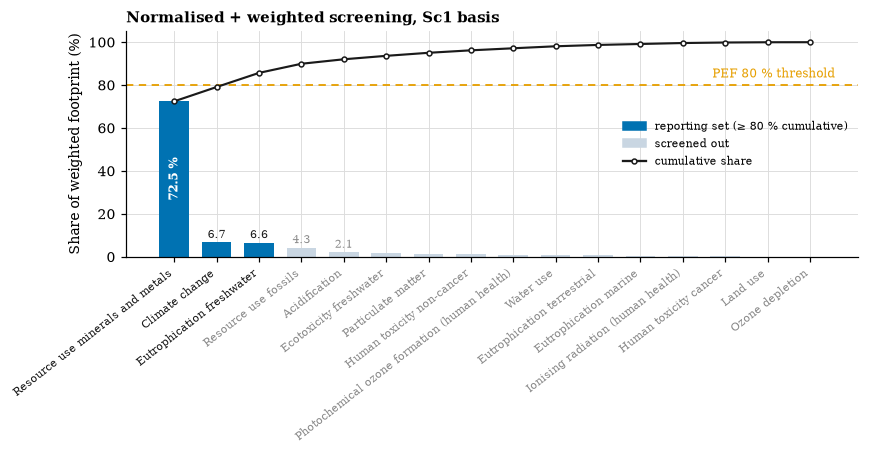

In [120]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(scr))
colors = [BLUE if k else "#c9d6e2" for k in scr.in_reporting_set]
bars = ax.bar(x, scr.share_pct, .7, color=colors)

ax.plot(x, scr.cum_pct, color="#1a1a1a", lw=1.4, marker="o", ms=3.2,
        mfc="white", mew=1.0, zorder=5)
ax.axhline(80, color=AMBER, lw=1.2, ls=(0, (4, 3)))
ax.annotate("PEF 80 % threshold", (len(scr) - .4, 80), (0, 5),
            textcoords="offset points", ha="right", fontsize=8, color=AMBER)

for bar, share, keep in zip(bars, scr.share_pct, scr.in_reporting_set):
    if share >= 25:                      # tall bar: label inside, rotated
        ax.annotate(f"{share:.1f} %", (bar.get_x() + bar.get_width()/2, share/2),
                    ha="center", va="center", rotation=90, fontsize=8,
                    color="white", fontweight="bold")
    elif keep or share >= 2:
        ax.annotate(f"{share:.1f}", (bar.get_x() + bar.get_width()/2, share), (0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5,
                    color="#1a1a1a" if keep else "#8a8a8a")

ax.set_xticks(x); ax.set_xticklabels(scr.category, rotation=38, ha="right", fontsize=7.5)
for t, keep in zip(ax.get_xticklabels(), scr.in_reporting_set):
    t.set_color("#1a1a1a" if keep else "#8a8a8a")
ax.set_ylabel("Share of weighted footprint (%)"); ax.set_ylim(0, 105)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color="#c9d6e2"),
           plt.Line2D([0], [0], color="#1a1a1a", marker="o", ms=3.2, mfc="white")]
ax.legend(handles, ["reporting set (≥ 80 % cumulative)", "screened out",
                    "cumulative share"], loc="center right", fontsize=7.5)
ax.set_title("Normalised + weighted screening, Sc1 basis")
fig.tight_layout(); save(fig, "p2_01_screening_pareto"); plt.show()

#### Analysing gross scenarios

In [121]:
# --- gross subset: three headline categories, gross columns only -------------
# sc1 is landfill, which has no recovery credit, so its single column IS the
# gross value -- there is no "sc1_gross" to pair with sc2..sc4.
COLS_GROSS = ["sc1", "sc2_gross", "sc3_gross", "sc4_gross"]

ef_gross = ef.loc[REPORTING, COLS_GROSS]

ef_gross

,sc1,sc2_gross,sc3_gross,sc4_gross
category,,,,
Resource use minerals and metals,0.018739,0.018740,0.018739,0.018740
Climate change,73.432586,73.479433,73.409331,73.410318
Eutrophication freshwater,0.115920,0.115935,0.115929,0.115937


saved: ef31_gross_by_scenario.png / .pdf


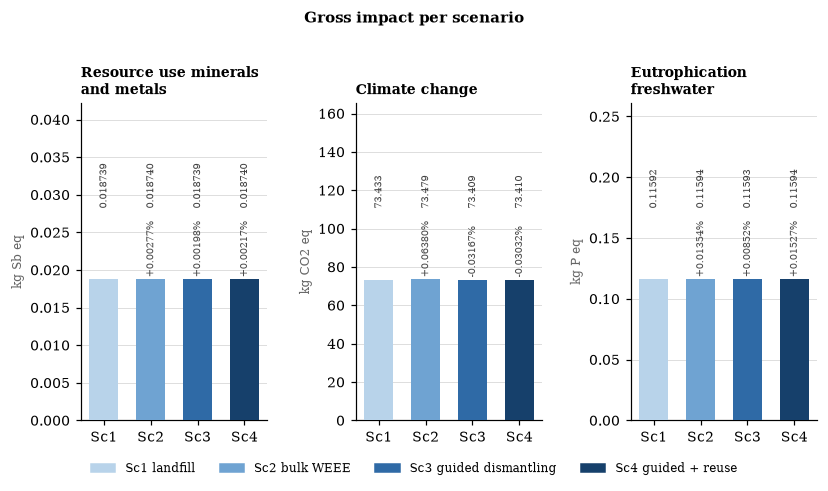

In [122]:
# --- chart: gross impact per scenario ----------------------------------------
# Three categories, three DIFFERENT units (kg Sb eq / kg CO2 eq / kg P eq), so
# they cannot share a y-axis -- small multiples, one panel and one scale each.
scen = [c.split("_")[0] for c in ef_gross.columns]      # sc1, sc2_gross -> sc2

fig, axes = plt.subplots(1, len(ef_gross), figsize=(7.6, 4.0))

for ax, cat in zip(axes, ef_gross.index):
    vals = ef_gross.loc[cat]
    ax.bar(range(len(scen)), vals, width=0.62,
           color=[SC_COLOR[s] for s in scen], zorder=3)

    # sig(v, 8) rather than a fixed decimal count: significant digits adapt to
    # each category's magnitude, so Climate change gets 6 decimals and Resource
    # use gets 9 -- 8 s.f. is the first precision that separates all four
    # scenarios in EVERY panel. Under it, the change vs Sc1 (the baseline).
    # 3 dp on the % because these gross gaps are ~0.03-0.06 %; the usual +.1f
    # would round every panel to +0.0 %.
    base = vals.iloc[0]
    for x, (s, v) in enumerate(zip(scen, vals)):
        ax.annotate(sig(v, 5), (x, v), (0, 48), textcoords="offset points",
                    ha="center", rotation=90, fontsize=6.5, color="#444")
        if s != "sc1":
            ax.annotate(f"{v / base - 1:+.5%}", (x, v), (0, 3),
                        textcoords="offset points", ha="center", rotation=90,
                        fontsize=6.5, color="#4d4d4d")

    ax.set_title(wrap(cat), fontsize=9, pad=6)
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(len(scen)))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in scen])
    ax.set_ylim(0, vals.max() * 2.25)   # bars start at zero; headroom for labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=SC_COLOR[s]) for s in scen]
fig.legend(handles, [SC_NAME[s] for s in scen], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.suptitle("Gross impact per scenario",
             x=0.5, y=1.02, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_gross_by_scenario")
plt.show()

#### Per stage

In [123]:
#=============================================================================
# Figure — contribution of life cycle stages 1 to 4, three reporting categories
# Placed in section 4.1 after Table 8 and the sentence
# "In every scenario, stages 1 to 4 are identical."
# Basis: the stage 1-4 subtotal = 100 %. Stage 5 is EXCLUDED and keeps its own
# table. The footnote states what the subtotal is worth against the gross, so
# the two bases can be reconciled by the reader.
# =============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
 
# --- locate the stage contribution file -------------------------------------
STAGE_CSV = find_data("impact_stage_contributions.csv")
assert STAGE_CSV.is_file(), "impact_stage_contributions.csv not found beside the notebook"
stg = pd.read_csv(STAGE_CSV)
stg["category"] = stg["category"].str.strip()
 
# --- the three reporting categories, exactly as spelled in that file ---------
CATS = [("Resource use minerals and metals", "Resource use, minerals and metals", "kg Sb eq"),
        ("Climate change",                   "Climate change",                   "kg CO2 eq"),
        ("Eutrophication freshwater",        "Eutrophication, freshwater",       "kg P eq")]
 
STAGES = [("s1", "S1 Materials and construction"),
          ("s2", "S2 Hardware assembly"),
          ("s3", "S3 Distribution"),
          ("s4", "S4 Use phase")]
 
# Okabe-Ito, colour-vision-deficiency safe. First three match the notebook palette.
STAGE_COLOR = {"s1": "#0072B2", "s2": "#E69F00", "s3": "#009E73", "s4": "#CC79A7"}
 
LABEL_FLOOR = 1.0        # slices below this are not labelled on the pie
SF          = 4          # significant figures in the table


In [124]:
# --- build the table ---------------------------------------------------------
rows = []
for key, nice, unit in CATS:
    r = stg.loc[stg["category"] == key]
    assert len(r) == 1, f"category not matched uniquely: {key}"
    r = r.iloc[0]
    vals   = np.array([float(r[s]) for s, _ in STAGES])
    sub14  = vals.sum()
    gross  = float(r["total_sc1"])
    shares = 100.0 * vals / sub14
    for (s, sname), v, sh in zip(STAGES, vals, shares):
        rows.append({"Category": nice, "Unit": unit, "Stage": sname,
                     "Impact": v, "Share of stages 1-4 (%)": sh})
    rows.append({"Category": nice, "Unit": unit, "Stage": "Total stages 1-4",
                 "Impact": sub14, "Share of stages 1-4 (%)": 100.0})
    rows.append({"Category": nice, "Unit": unit, "Stage": "Stages 1-4 as share of gross (%)",
                 "Impact": np.nan, "Share of stages 1-4 (%)": 100.0 * sub14 / gross})
 
stage_tbl = pd.DataFrame(rows)
stage_tbl

,Category,Unit,Stage,Impact,Share of stages 1-4 (%)
0,"Resource use, minerals and metals",kg Sb eq,S1 Materials and construction,1.833495e-02,97.843335
1,"Resource use, minerals and metals",kg Sb eq,S2 Hardware assembly,8.338095e-05,0.444957
2,"Resource use, minerals and metals",kg Sb eq,S3 Distribution,6.226076e-08,0.000332
3,"Resource use, minerals and metals",kg Sb eq,S4 Use phase,3.206961e-04,1.711375
4,"Resource use, minerals and metals",kg Sb eq,Total stages 1-4,1.873909e-02,100.000000
5,"Resource use, minerals and metals",kg Sb eq,Stages 1-4 as share of gross (%),NaN,99.999840
6,Climate change,kg CO2 eq,S1 Materials and construction,3.848759e+01,52.538430
7,Climate change,kg CO2 eq,S2 Hardware assembly,4.408816e-01,0.601836
8,Climate change,kg CO2 eq,S3 Distribution,2.791567e-02,0.038107
9,Climate change,kg CO2 eq,S4 Use phase,3.429968e+01,46.821627


In [125]:
# --- verification, refuses to draw a chart that does not add up --------------
for key, nice, unit in CATS:
    r = stg.loc[stg["category"] == key].iloc[0]
    vals = np.array([float(r[s]) for s, _ in STAGES])
    sub  = stage_tbl.loc[(stage_tbl["Category"] == nice) &
                         (stage_tbl["Stage"] == "Total stages 1-4"), "Impact"].iloc[0]
    assert np.isclose(vals.sum(), sub, rtol=0, atol=1e-15), f"subtotal mismatch: {nice}"
    sh = stage_tbl.loc[(stage_tbl["Category"] == nice) &
                       (stage_tbl["Stage"].isin([n for _, n in STAGES])),
                       "Share of stages 1-4 (%)"].sum()
    assert abs(sh - 100.0) < 1e-9, f"shares do not close on 100: {nice} = {sh}"
    # stage 5 must NOT be inside this basis
    assert "s5_sc1" in stg.columns and float(r["s5_sc1"]) not in vals, "stage 5 leaked into the pie"
print("checks passed: three categories, four stages, shares close on 100 %")

checks passed: three categories, four stages, shares close on 100 %


saved: fig_stage_contribution_pies.png / .pdf


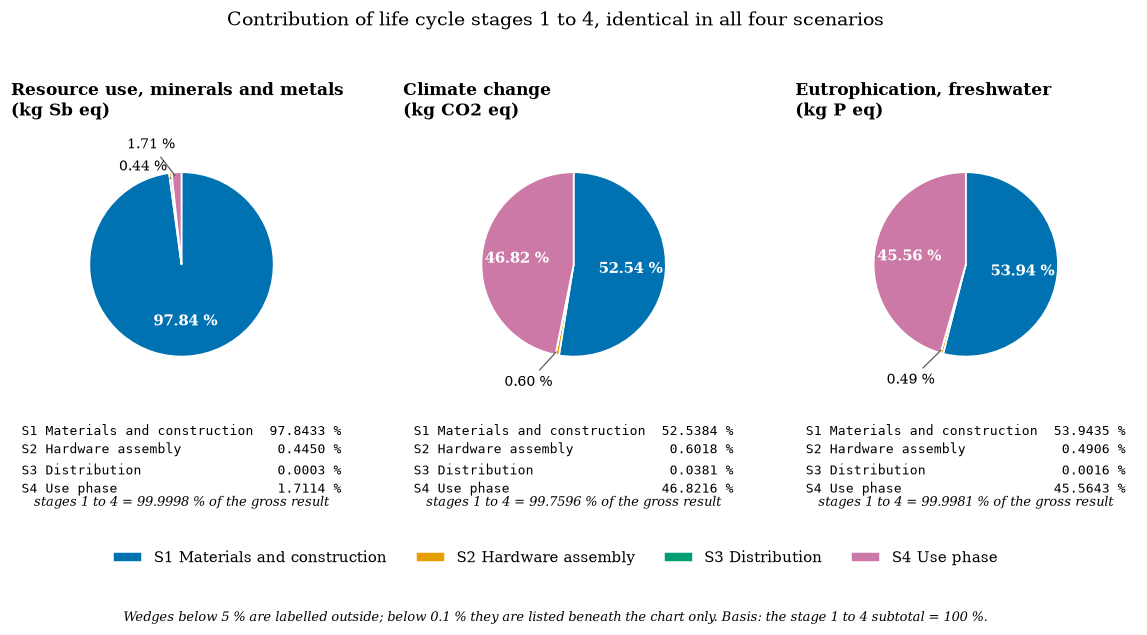

In [126]:
# --- the figure --------------------------------------------------------------
INSIDE_FLOOR  = 5.0      # labelled inside the wedge
OUTSIDE_FLOOR = 0.1      # labelled outside with a leader; below this, table only
 
fig, axes = plt.subplots(1, 3, figsize=(13.2, 5.9))
plt.subplots_adjust(bottom=0.30, top=0.86, wspace=0.15)
 
for ax, (key, nice, unit) in zip(axes, CATS):
    r      = stg.loc[stg["category"] == key].iloc[0]
    vals   = np.array([float(r[s]) for s, _ in STAGES])
    shares = 100.0 * vals / vals.sum()
    frac   = 100.0 * vals.sum() / float(r["total_sc1"])
 
    wedges, _, autotexts = ax.pie(
        vals,
        colors=[STAGE_COLOR[s] for s, _ in STAGES],
        startangle=90, counterclock=False,
        autopct=lambda p: f"{p:.2f} %" if p >= INSIDE_FLOOR else "",
        pctdistance=0.62,
        wedgeprops=dict(edgecolor="white", linewidth=1.1),
        textprops=dict(fontsize=10),
    )
    for t in autotexts:
        t.set_color("white"); t.set_fontweight("bold")
 
    # slices too thin to label inside get a leader line to the outside,
    # de-collided vertically so two adjacent thin wedges do not print on top
    # of each other (minerals has two of them within one degree)
    ax.set_xlim(-1.85, 1.85); ax.set_ylim(-1.30, 1.45)
    outs = []
    for w, sh in zip(wedges, shares):
        if OUTSIDE_FLOOR <= sh < INSIDE_FLOOR:
            ang = np.deg2rad((w.theta1 + w.theta2) / 2.0)
            outs.append((np.cos(ang), np.sin(ang), sh))
    outs.sort(key=lambda t: -t[1])
    placed = []
    for x, y, sh in outs:
        tx, ty = 1.30 * x, 1.30 * y
        for px, py in placed:
            if abs(ty - py) < 0.24 and (tx >= 0) == (px >= 0):
                ty = py - 0.24
        placed.append((tx, ty))
        ax.annotate(f"{sh:.2f} %", xy=(0.94 * x, 0.94 * y), xytext=(tx, ty),
                    ha="left" if tx >= 0 else "right", va="center", fontsize=9,
                    arrowprops=dict(arrowstyle="-", lw=0.8, color="0.35",
                                    connectionstyle="arc3,rad=0.0"))
 
    ax.set_title(f"{nice}\n({unit})", fontsize=11, fontweight="bold", pad=10)
 
    # every stage listed under its pie, including the ones with no visible wedge
    block = "\n".join(f"{n:<30s}{sh:8.4f} %" for (_, n), sh in zip(STAGES, shares))
    ax.text(0.5, -0.14, block, transform=ax.transAxes, ha="center", va="top",
            fontsize=8.6, family="DejaVu Sans Mono", linespacing=1.5)
    ax.text(0.5, -0.44, f"stages 1 to 4 = {frac:.4f} % of the gross result",
            transform=ax.transAxes, ha="center", va="top", fontsize=8.6, style="italic")
 
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, facecolor=STAGE_COLOR[s], edgecolor="white")
                    for s, _ in STAGES],
           labels=[n for _, n in STAGES],
           loc="lower center", ncol=4, frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.5, 0.085))
fig.suptitle("Contribution of life cycle stages 1 to 4, identical in all four scenarios",
             fontsize=12.5, y=0.96)
fig.text(0.5, 0.020,
         f"Wedges below {INSIDE_FLOOR:.0f} % are labelled outside; below {OUTSIDE_FLOOR:g} % "
         "they are listed beneath the chart only. Basis: the stage 1 to 4 subtotal = 100 %.",
         ha="center", fontsize=8.4, style="italic")
 
try:
    save(fig, "fig_stage_contribution_pies")     # notebook helper, cell 3
except NameError:
    fig.savefig("fig_stage_contribution_pies.png", dpi=300, bbox_inches="tight")
    fig.savefig("fig_stage_contribution_pies.svg", bbox_inches="tight")
plt.show()

In [127]:
# --- the table, printed and written for the thesis ---------------------------
# Wide layout, the shape a body table needs: one row per stage, one column pair
# per category. The long frame above is kept only for the checks.
wide = {}
for key, nice, unit in CATS:
    r      = stg.loc[stg["category"] == key].iloc[0]
    vals   = np.array([float(r[s_]) for s_, _ in STAGES])
    shares = 100.0 * vals / vals.sum()
    wide[(nice, f"Impact ({unit})")] = list(vals) + [vals.sum()]
    wide[(nice, "Share (%)")]        = list(shares) + [100.0]
 
stage_body = pd.DataFrame(wide, index=[n for _, n in STAGES] + ["Total stages 1 to 4"])
stage_body.index.name = "Life cycle stage"
stage_body.columns = pd.MultiIndex.from_tuples(stage_body.columns)
 
fmt = {}
for key, nice, unit in CATS:
    fmt[(nice, f"Impact ({unit})")] = "{:.4g}".format
    fmt[(nice, "Share (%)")]        = "{:.4f}".format
print(stage_body.to_string(formatters=fmt))
print()
for key, nice, unit in CATS:
    r = stg.loc[stg["category"] == key].iloc[0]
    sub = sum(float(r[s_]) for s_, _ in STAGES)
    print(f"{nice}: stages 1 to 4 = {100.0 * sub / float(r['total_sc1']):.4f} % of the gross result")
 
with pd.ExcelWriter("stage_1_to_4_contributions.xlsx") as xl:
    stage_body.to_excel(xl, sheet_name="body_table")
    stage_tbl.to_excel(xl, sheet_name="long_form", index=False)

                              Resource use, minerals and metals               Climate change           Eutrophication, freshwater          
                                              Impact (kg Sb eq) Share (%) Impact (kg CO2 eq) Share (%)           Impact (kg P eq) Share (%)
Life cycle stage                                                                                                                           
S1 Materials and construction                           0.01833   97.8433              38.49   52.5384                    0.06253   53.9435
S2 Hardware assembly                                  8.338e-05    0.4450             0.4409    0.6018                  0.0005687    0.4906
S3 Distribution                                       6.226e-08    0.0003            0.02792    0.0381                  1.806e-06    0.0016
S4 Use phase                                          0.0003207    1.7114               34.3   46.8216                    0.05282   45.5643
Total stages 1 to 4 

#### Analysing savings scenario

In [128]:
# --- saving subset: three headline categories, saving columns only -------------
# sc1 is landfill, which has no recovery credit, so its single column IS the
# saving value -- there is no "sc1_saving" to pair with sc2..sc4.
COLS_saving = ["sc2_saving", "sc3_saving", "sc4_saving"]

ef_saving = ef.loc[REPORTING, COLS_saving]

ef_saving

,sc2_saving,sc3_saving,sc4_saving
category,,,
Resource use minerals and metals,0.001872,0.006026,0.008870
Climate change,4.418978,8.162726,15.431529
Eutrophication freshwater,0.006899,0.019143,0.029761


saved: ef31_saving_by_scenario.png / .pdf


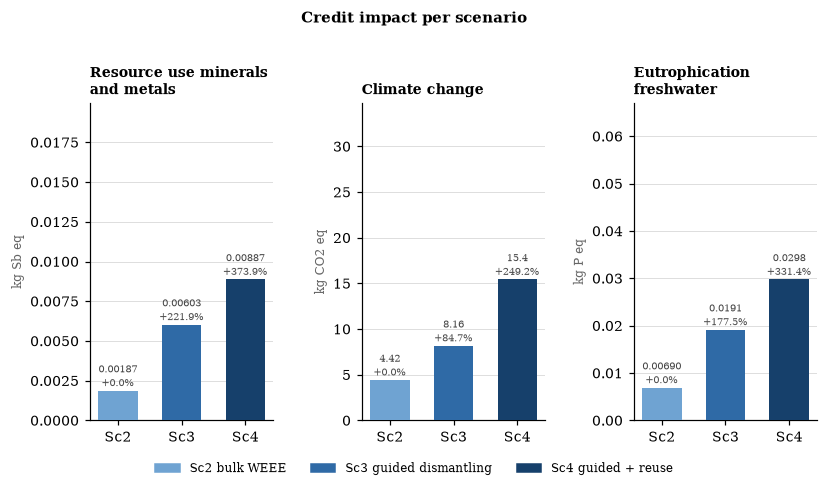

In [129]:
# --- chart: saving impact per scenario ----------------------------------------
# Three categories, three DIFFERENT units (kg Sb eq / kg CO2 eq / kg P eq), so
# they cannot share a y-axis -- small multiples, one panel and one scale each.
scen = [c.split("_")[0] for c in ef_saving.columns]      # sc1, sc2_saving -> sc2

fig, axes = plt.subplots(1, len(ef_saving), figsize=(7.6, 4.0))

for ax, cat in zip(axes, ef_saving.index):
    vals = ef_saving.loc[cat]
    ax.bar(range(len(scen)), vals, width=0.62,
           color=[SC_COLOR[s] for s in scen], zorder=3)

    # sig(v, 8) rather than a fixed decimal count: significant digits adapt to
    # each category's magnitude, so Climate change gets 6 decimals and Resource
    # use gets 9 -- 8 s.f. is the first precision that separates all four
    # scenarios in EVERY panel. Under it, the change vs Sc1 (the baseline).
    # 3 dp on the % because these saving gaps are ~0.03-0.06 %; the usual +.1f
    # would round every panel to +0.0 %.
    base = vals.iloc[0]
    for x, (s, v) in enumerate(zip(scen, vals)):
        ax.annotate(sig(v, 3), (x, v), (0, 12), textcoords="offset points",
                    ha="center", fontsize=6.5, color="#444")
        if s != "sc1":
            ax.annotate(f"{v / base - 1:+.1%}", (x, v), (0, 3),
                        textcoords="offset points", ha="center",
                        fontsize=6.5, color="#4d4d4d")

    ax.set_title(wrap(cat), fontsize=9, pad=6)
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(len(scen)))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in scen])
    ax.set_ylim(0, vals.max() * 2.25)   # bars start at zero; headroom for labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=SC_COLOR[s]) for s in scen]
fig.legend(handles, [SC_NAME[s] for s in scen], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.suptitle("Credit impact per scenario",
             x=0.5, y=1.02, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_saving_by_scenario")
plt.show()

#### Analysing net scenario

In [130]:
# --- net subset: three headline categories, net columns only -------------
# sc1 is landfill, which has no recovery credit, so its single column IS the
# net value -- there is no "sc1_net" to pair with sc2..sc4.
COLS_net = ["sc1", "sc2_net", "sc3_net", "sc4_net"]

ef_net = ef.loc[REPORTING, COLS_net]

ef_net

,sc1,sc2_net,sc3_net,sc4_net
category,,,,
Resource use minerals and metals,0.018739,0.016868,0.012714,0.009869
Climate change,73.432586,69.060455,65.246605,57.978789
Eutrophication freshwater,0.115920,0.109036,0.096787,0.086176


saved: ef31_net_by_scenario.png / .pdf


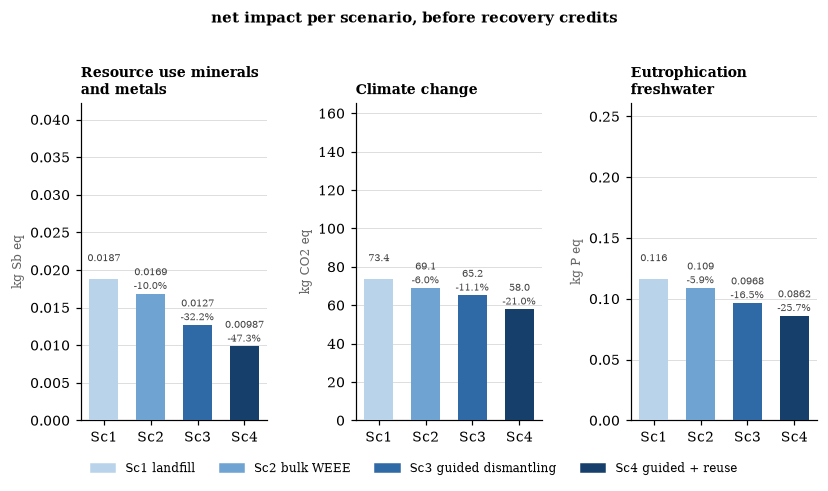

In [131]:
# --- chart: net impact per scenario ----------------------------------------
# Three categories, three DIFFERENT units (kg Sb eq / kg CO2 eq / kg P eq), so
# they cannot share a y-axis -- small multiples, one panel and one scale each.
scen = [c.split("_")[0] for c in ef_net.columns]      # sc1, sc2_net -> sc2

fig, axes = plt.subplots(1, len(ef_net), figsize=(7.6, 4.0))

for ax, cat in zip(axes, ef_net.index):
    vals = ef_net.loc[cat]
    ax.bar(range(len(scen)), vals, width=0.62,
           color=[SC_COLOR[s] for s in scen], zorder=3)

    # sig(v, 8) rather than a fixed decimal count: significant digits adapt to
    # each category's magnitude, so Climate change gets 6 decimals and Resource
    # use gets 9 -- 8 s.f. is the first precision that separates all four
    # scenarios in EVERY panel. Under it, the change vs Sc1 (the baseline).
    # 3 dp on the % because these net gaps are ~0.03-0.06 %; the usual +.1f
    # would round every panel to +0.0 %.
    base = vals.iloc[0]
    for x, (s, v) in enumerate(zip(scen, vals)):
        ax.annotate(sig(v, 3), (x, v), (0, 12), textcoords="offset points",
                    ha="center", fontsize=6.5, color="#444")
        if s != "sc1":
            ax.annotate(f"{v / base - 1:+.1%}", (x, v), (0, 3),
                        textcoords="offset points", ha="center",
                        fontsize=6.5, color="#4d4d4d")

    ax.set_title(wrap(cat), fontsize=9, pad=6)
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(len(scen)))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in scen])
    ax.set_ylim(0, vals.max() * 2.25)   # bars start at zero; headroom for labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=SC_COLOR[s]) for s in scen]
fig.legend(handles, [SC_NAME[s] for s in scen], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.suptitle("net impact per scenario, before recovery credits",
             x=0.5, y=1.02, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_net_by_scenario")
plt.show()

**Net reduction vs Sc1 — all 25 categories**

saved: ef31_reduction_heatmap.png / .pdf


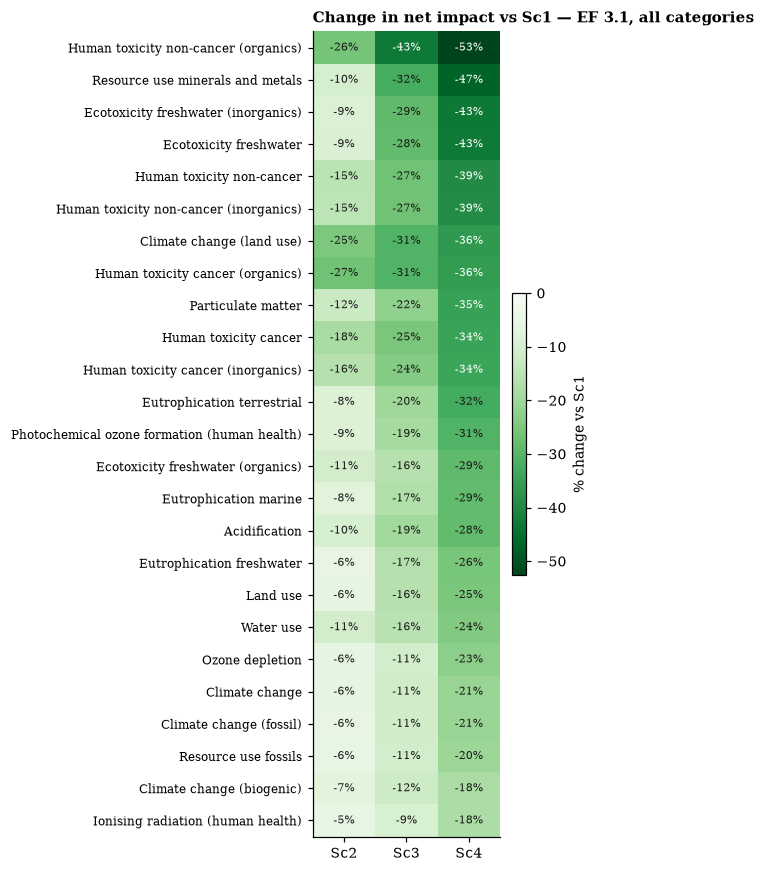

In [132]:
# --- heat map: net change vs Sc1, every category ------------------------------
# Percentages are unitless, so unlike the bar chart above all 25 categories CAN
# share one scale. Sc1 is the baseline and would be a column of zeros, so only
# Sc2..Sc4 are drawn.
NET = ["sc2", "sc3", "sc4"]

pct = pd.DataFrame({sc: (ef[f"{sc}_net"] / ef["sc1"] - 1) * 100 for sc in NET})
pct = pct.sort_values("sc4")            # best performer under Sc4 at the top

fig, ax = plt.subplots(figsize=(5.2, 8))
# Every value is a reduction (-53%..-5%), so this is a one-directional
# magnitude scale: a single hue, light -> dark. vmax=0 anchors "no change" to
# white. Re-check that if a category ever comes out positive -- it would clip.
im = ax.imshow(pct.values, cmap="Greens_r", aspect="auto",
               vmin=pct.values.min(), vmax=0)

for i in range(pct.shape[0]):
    for j in range(pct.shape[1]):
        v = pct.values[i, j]
        # Pick the text colour from the cell's own luminance rather than a
        # fixed cut-off, so mid-green cells keep dark text and stay legible.
        r, g, b, _ = im.cmap(im.norm(v))
        lum = 0.299 * r + 0.587 * g + 0.114 * b
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=7.5,
                color="white" if lum < 0.5 else "#1a1a1a")

ax.set_xticks(range(len(NET)))
ax.set_xticklabels([s.replace("sc", "Sc") for s in NET])
ax.set_yticks(range(len(pct)))
ax.set_yticklabels(pct.index, fontsize=8)
ax.set_title("Change in net impact vs Sc1 — EF 3.1, all categories")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=.35, label="% change vs Sc1")
fig.tight_layout()

save(fig, "ef31_reduction_heatmap")
plt.show()

#### **Where the reduction comes from — gross split into net and credit**

saved: ef31_gross_vs_credit.png / .pdf


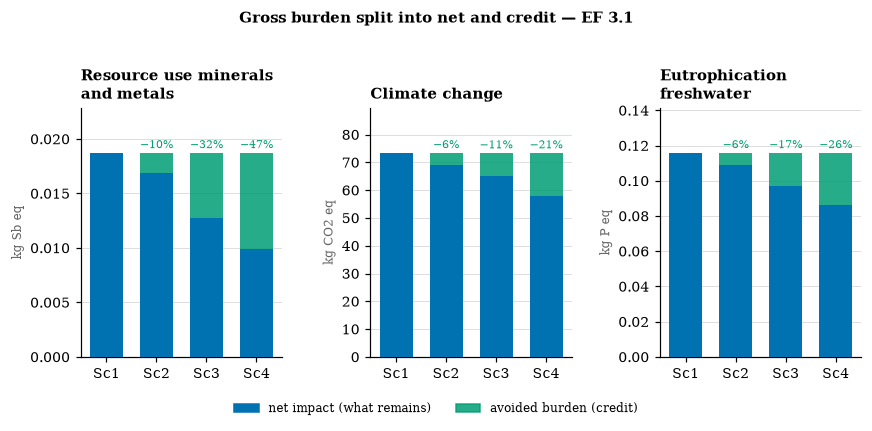

In [133]:
# --- chart: gross burden split into net + credit ------------------------------
# Each bar totals the GROSS value (verified: gross - saving == net for all 25
# categories). Blue is what remains, green is the recovery credit -- so this is
# the same gross bar as further up, now cut to show where the reduction comes
# from. Sc1 is landfill: no credit, so the bar is entirely blue.
fig, axes = plt.subplots(1, len(REPORTING), figsize=(8.0, 3.4))

for ax, cat in zip(axes, REPORTING):
    r = ef.loc[cat]
    nets = np.array([r["sc1"]] + [r[f"{sc}_net"]    for sc in SCEN[1:]])
    sav  = np.array([0.0]      + [r[f"{sc}_saving"] for sc in SCEN[1:]])

    ax.bar(range(4), nets, .66, color=BLUE, zorder=3)
    ax.bar(range(4), sav, .66, bottom=nets, color=GREEN, alpha=.85, zorder=3)

    # Credit as a share of gross -- i.e. the reduction vs that scenario's own
    # gross bar. Sc1 has no credit, so it gets no label.
    for i, (n, s) in enumerate(zip(nets, sav)):
        if s > 0:
            ax.annotate(f"−{s / (n + s) * 100:.0f}%", (i, n + s), (0, 3),
                        textcoords="offset points", ha="center",
                        fontsize=7.5, color=GREEN)

    ax.set_title(wrap(cat))
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(4))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in SCEN])
    ax.set_ylim(0, (nets + sav).max() * 1.22)
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color=GREEN, alpha=.85)]
fig.legend(handles, ["net impact (what remains)", "avoided burden (credit)"],
           loc="lower center", ncol=2, bbox_to_anchor=(.5, -.08), fontsize=8)
fig.suptitle("Gross burden split into net and credit — EF 3.1",
             x=0.5, y=1.03, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_gross_vs_credit")
plt.show()

saved: ef31_balance_by_scenario.png / .pdf


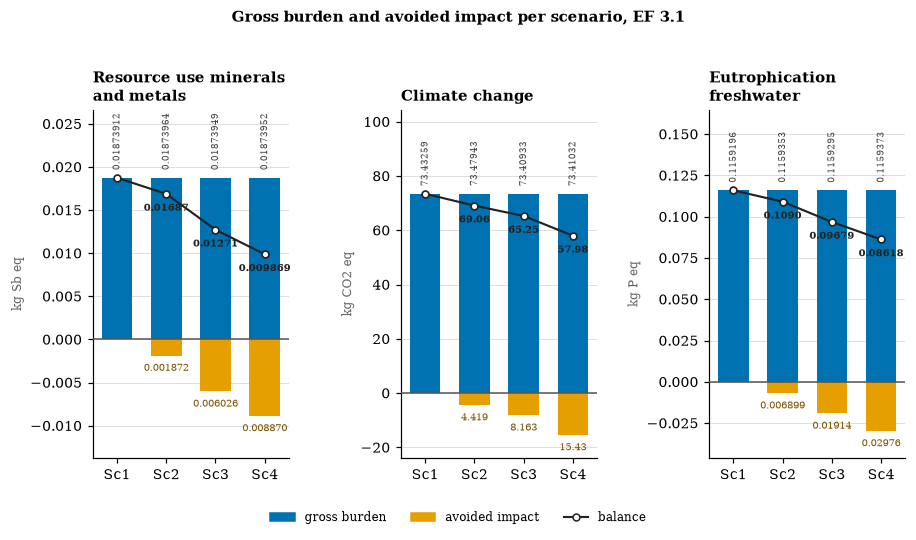

In [134]:
# --- chart: gross burden and avoided impact on one axis, with the balance -----
# The supervisor's reporting convention: the gross burden is drawn ABOVE the
# zero line, the avoided impact BELOW it, and the two are never added into a
# single bar. The balance line is gross minus avoided, drawn as a line rather
# than a bar so it reads as a derived quantity and not as a third measurement.
# Sc1 recovers nothing, so it has no avoided impact and its balance equals its
# gross burden.
#
# GROSS_SF = 7 because seven significant figures is the FIRST precision that
# separates all four scenarios in every panel: minerals needs 7, freshwater
# eutrophication needs 6 and climate change needs 5. (The 8 s.f. noted earlier
# in this notebook was derived on the saving columns, not the gross ones.)
# The gross labels are rotated because at that width they collide horizontally.
# The avoided impact and the balance differ at the third digit, so they stay at
# 4 s.f.; printing seven there would suggest a precision the reader does not
# need in order to tell the bars apart.

# --- number formatting for this chart ----------------------------------------
# `sig` gives significant figures in plain decimal. That is the right form here,
# because at 1e-2 magnitude the scientific version is LONGER: 1.873912e-02
# against 0.01873912. Scientific only earns its place once the magnitude leaves
# the range a reader can scan, so `smart` switches to it below 1e-3 or at or
# above 1e5 and otherwise returns `sig` unchanged. Nothing in the three
# reporting categories triggers it; it matters if this cell is ever pointed at
# human toxicity or at stage 5, where values reach 1e-08.
def smart(v, n):
    if v == 0 or not np.isfinite(v):
        return "0"
    if abs(v) < 1e-3 or abs(v) >= 1e5:
        return f"{v:.{n - 1}e}"
    return sig(v, n)


GROSS_C, AVOID_C, BAL_C = BLUE, AMBER, "#222222"
GROSS_SF, OTHER_SF = 7, 4

fig, axes = plt.subplots(1, len(REPORTING), figsize=(8.4, 4.3))

for ax, cat in zip(axes, REPORTING):
    r     = ef.loc[cat]
    gross = np.array([r["sc1"]] + [r[f"{sc}_gross"]  for sc in SCEN[1:]])
    avoid = np.array([0.0]      + [r[f"{sc}_saving"] for sc in SCEN[1:]])
    bal   = gross - avoid

    # The identity is asserted rather than trusted: the balance must reproduce
    # the model's own subtraction in every category.
    chk = np.array([r["sc1"]] + [r[f"{sc}_net"] for sc in SCEN[1:]])
    assert np.allclose(bal, chk, rtol=0, atol=1e-12), f"balance mismatch in {cat}"

    ax.bar(range(4),  gross, .62, color=GROSS_C, zorder=3)
    ax.bar(range(4), -avoid, .62, color=AVOID_C, zorder=3)
    ax.axhline(0, color="#555", lw=1.0, zorder=4)

    ax.plot(range(4), bal, color=BAL_C, lw=1.4, marker="o", ms=4.5,
            markerfacecolor="white", markeredgewidth=1.1, zorder=6)

    for x, (g, a, b) in enumerate(zip(gross, avoid, bal)):
        ax.annotate(smart(g, GROSS_SF), (x, g), (0, 5), textcoords="offset points",
                    ha="center", va="bottom", rotation=90,
                    fontsize=6.2, color="#444")
        if a > 0:
            ax.annotate(smart(a, OTHER_SF), (x, -a), (0, -10),
                        textcoords="offset points", ha="center",
                        fontsize=6.5, color="#7a5400")
        # Sc1 has no credit, so its balance equals its gross burden and the
        # label would print on top of the one above. Marker only for Sc1.
        if x > 0:
            ax.annotate(smart(b, OTHER_SF), (x, b), (0, -11),
                        textcoords="offset points", ha="center",
                        fontsize=6.5, color=BAL_C, fontweight="bold")

    ax.set_title(wrap(cat))
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(4))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in SCEN])
    ax.set_ylim(-avoid.max() * 1.55, gross.max() * 1.42)   # headroom for the rotated labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=GROSS_C),
           plt.Rectangle((0, 0), 1, 1, color=AVOID_C),
           plt.Line2D([0], [0], color=BAL_C, lw=1.4, marker="o", ms=4.5,
                      markerfacecolor="white")]
fig.legend(handles, ["gross burden", "avoided impact", "balance"],
           loc="lower center", ncol=3, bbox_to_anchor=(.5, -.08), fontsize=8)
fig.suptitle("Gross burden and avoided impact per scenario, EF 3.1",
             x=0.5, y=1.03, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.2)

save(fig, "ef31_balance_by_scenario")
plt.show()

## **Monte Carlo — does the deterministic run sit at the centre?**

#####  Load the Monte Carlo draws 

In [135]:
SYSTEMS = ["Sc1", "Sc2g", "Sc2s", "Sc3g", "Sc3s", "Sc4g", "Sc4s"]

runs = {}
for k in SYSTEMS:
    p = MC / f"mc_raw_{k}.csv"
    if p.exists():
        runs[k] = pd.read_csv(p).set_index("iteration")

missing = [k for k in SYSTEMS if k not in runs]
print("exports found :", ", ".join(runs) or "none")
print("still missing :", ", ".join(missing) or "none - all seven complete")
if runs:
    k0 = next(iter(runs))
    print(f"\n{k0}: {runs[k0].shape[0]} runs x {runs[k0].shape[1]} categories")

exports found : Sc1, Sc2g, Sc2s, Sc3g, Sc3s, Sc4g, Sc4s
still missing : none - all seven complete

Sc1: 1000 runs x 25 categories


#### Deterministic vs Monte Carlo, Sc1 

In [136]:

# `ef` here is WIDE (one row per category), so there is no .scenario column to
# filter on -- the Sc1 net is simply the "sc1" column. Landfill earns no
# recovery credit, so for Sc1 net == gross == sc1.
if "Sc1" in runs:
    det = ef["sc1"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc1"]:
            s = runs["Sc1"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.2f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc1 export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018739,0.018950,1.01×
1,Climate change,kg CO2 eq,73.432586,94.380511,1.29×
2,Eutrophication freshwater,kg P eq,0.115920,0.149132,1.29×


saved: ef31_mc_distribution_sc1_all.png / .pdf


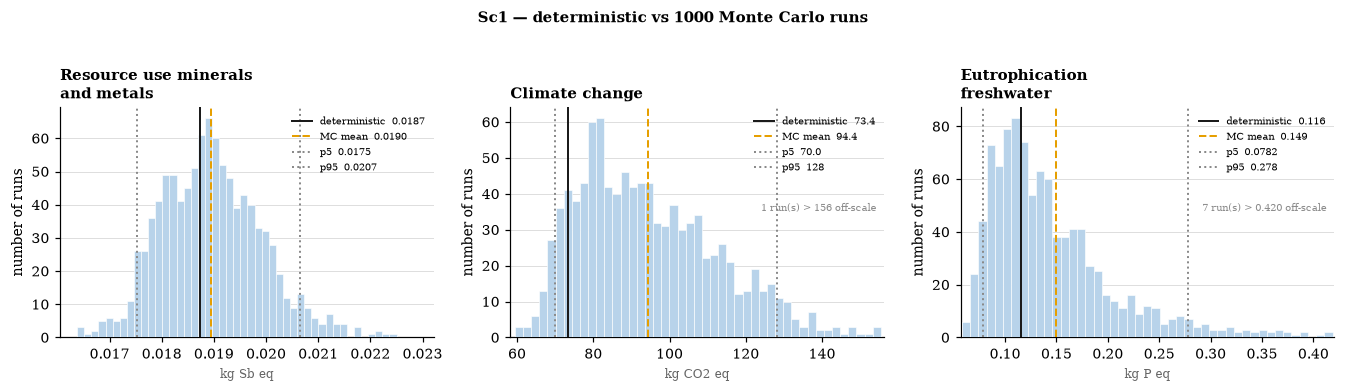

In [137]:
# --- Sc1: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc1" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc1"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc1"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc1's net
        # is the "sc1" column (landfill earns no credit, so net == gross == sc1).
        det_val = ef.loc[cat, "sc1"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc1"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc1 — deterministic vs {len(runs['Sc1'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_sc1_all")
    plt.show()
else:
    print("Sc1 export not available yet — skipping.")


#### Deterministic vs Monte Carlo, Sc2

##### Deterministic vs Monte Carlo, Sc2 gross

In [138]:
if "Sc2g" in runs:
    det = ef["sc2_gross"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc2g"]:
            s = runs["Sc2g"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.2f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc2g export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018740,0.018943,1.01×
1,Climate change,kg CO2 eq,73.479433,92.006242,1.25×
2,Eutrophication freshwater,kg P eq,0.115935,0.145155,1.25×


saved: ef31_mc_distribution_Sc2g_all.png / .pdf


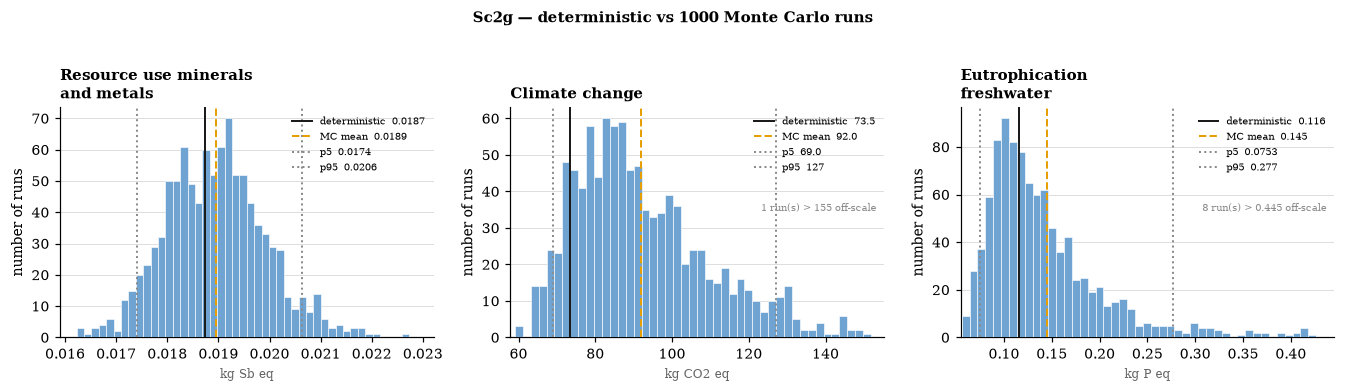

In [139]:
# --- Sc2g: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc2g" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc2g"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc2g"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc2g's net
        # is the "Sc2_gross" column (landfill earns no credit, so net == gross == Sc2_gross).
        det_val = ef.loc[cat, "sc2_gross"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc2"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc2g — deterministic vs {len(runs['Sc2g'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc2g_all")
    plt.show()
else:
    print("Sc2g export not available yet — skipping.")


##### Deterministic vs Monte Carlo, Sc2 savings

In [140]:
if "Sc2s" in runs:
    det = ef["sc2_saving"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc2s"]:
            s = runs["Sc2s"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.2f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc2s export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.001872,0.001873,1.00×
1,Climate change,kg CO2 eq,4.418978,4.647598,1.05×
2,Eutrophication freshwater,kg P eq,0.006899,0.006974,1.01×


saved: ef31_mc_distribution_Sc2s_all.png / .pdf


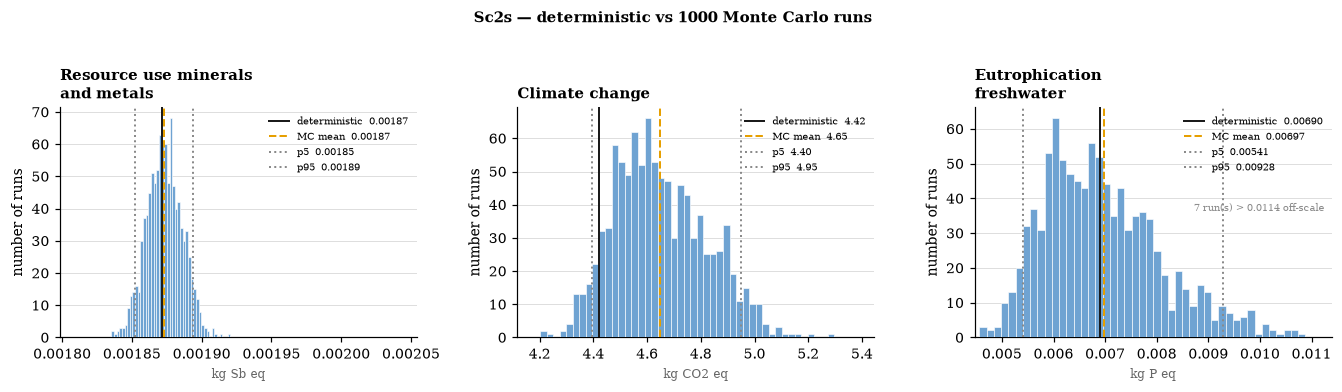

In [141]:
# --- Sc2s: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc2s" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc2s"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc2s"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc2s's net
        # is the "Sc2_saving" column (landfill earns no credit, so net == gross == Sc2_saving).
        det_val = ef.loc[cat, "sc2_saving"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc2"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc2s — deterministic vs {len(runs['Sc2s'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc2s_all")
    plt.show()
else:
    print("Sc2s export not available yet — skipping.")


#### Deterministic vs Monte Carlo, Sc3

##### Deterministic vs Monte Carlo, Sc3 gross

In [142]:
if "Sc3g" in runs:
    det = ef["sc3_gross"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc3g"]:
            s = runs["Sc3g"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.3f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc3g export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018739,0.018956,1.012×
1,Climate change,kg CO2 eq,73.409331,94.546568,1.288×
2,Eutrophication freshwater,kg P eq,0.115929,0.146910,1.267×


saved: ef31_mc_distribution_Sc3g_all.png / .pdf


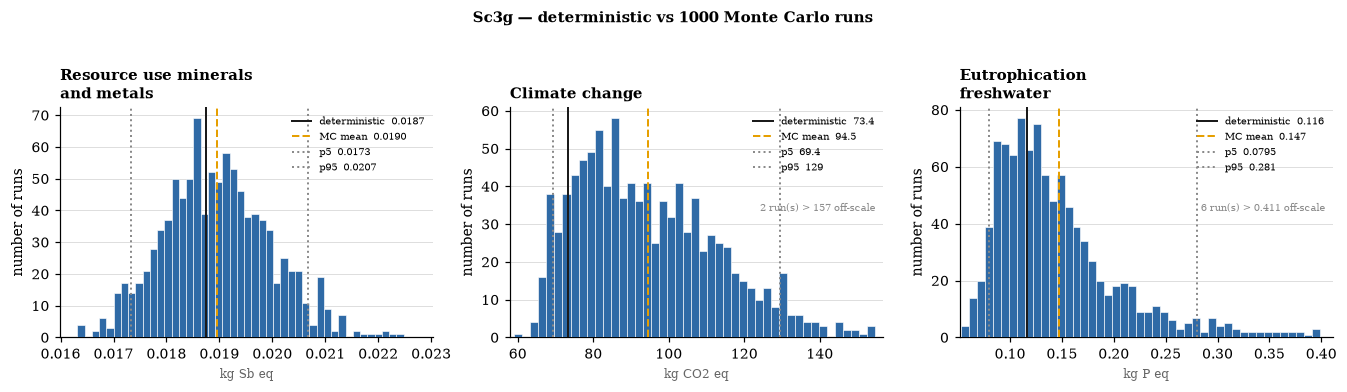

In [143]:
# --- Sc3g: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc3g" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc3g"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc3g"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc3g's net
        # is the "Sc3g" column (landfill earns no credit, so net == gross == Sc3g).
        det_val = ef.loc[cat, "sc3_gross"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc3"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc3g — deterministic vs {len(runs['Sc3g'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc3g_all")
    plt.show()
else:
    print("Sc3g export not available yet — skipping.")


##### Deterministic vs Monte Carlo, Sc3 savings

In [144]:
if "Sc3s" in runs:
    det = ef["sc3_saving"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc3s"]:
            s = runs["Sc3s"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.3f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc3s export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.006026,0.005953,0.988×
1,Climate change,kg CO2 eq,8.162726,8.423508,1.032×
2,Eutrophication freshwater,kg P eq,0.019143,0.019041,0.995×


saved: ef31_mc_distribution_Sc3s_all.png / .pdf


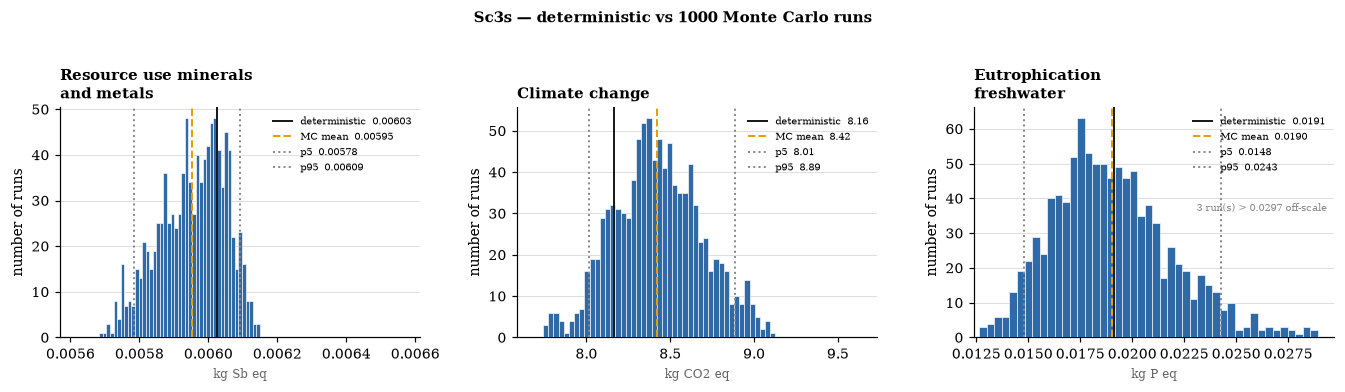

In [145]:
# --- Sc3s: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc3s" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc3s"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc3s"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc3s's net
        # is the "Sc3s" column (landfill earns no credit, so net == gross == Sc3s).
        det_val = ef.loc[cat, "sc3_saving"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc3"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc3s — deterministic vs {len(runs['Sc3s'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc3s_all")
    plt.show()
else:
    print("Sc3s export not available yet — skipping.")

#### Deterministic vs Monte Carlo, Sc4

##### Deterministic vs Monte Carlo, Sc4 gross

In [146]:
if "Sc4g" in runs:
    det = ef["sc4_gross"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc4g"]:
            s = runs["Sc4g"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.4f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc4g export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018740,0.018988,1.0132×
1,Climate change,kg CO2 eq,73.410318,93.494533,1.2736×
2,Eutrophication freshwater,kg P eq,0.115937,0.142824,1.2319×


saved: ef41_mc_distribution_Sc4g_all.png / .pdf


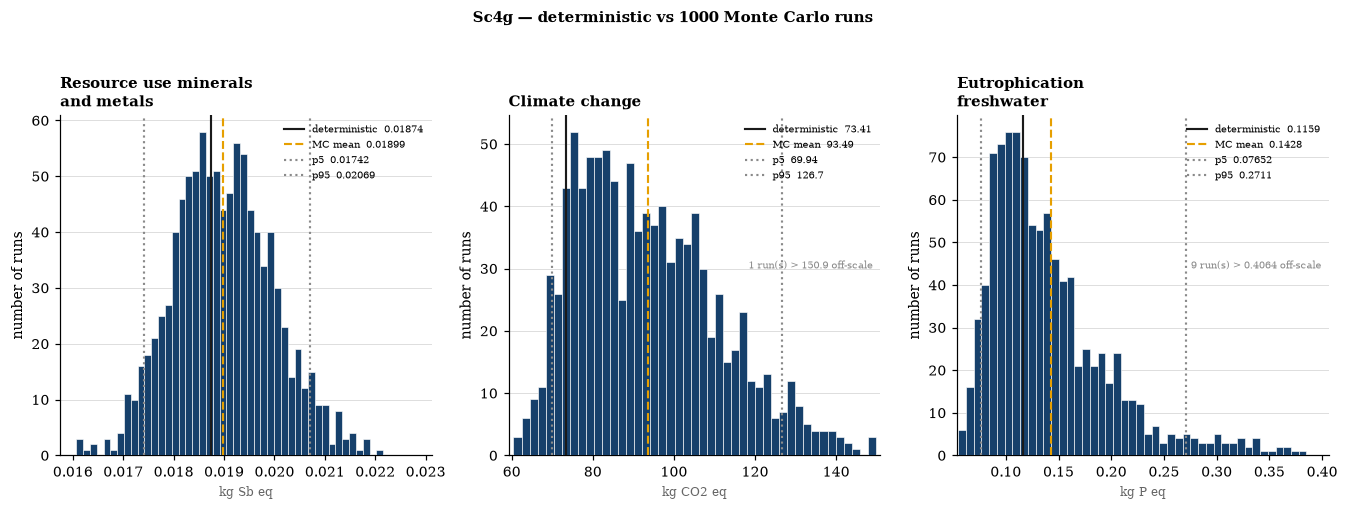

In [147]:
# --- Sc4g: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc4g" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc4g"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 4.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc4g"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc4g's net
        # is the "Sc4g" column (landfill earns no credit, so net == gross == Sc4g).
        det_val = ef.loc[cat, "sc4_gross"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc4"], edgecolor="white",
                linewidth=.4, zorder=4)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 4)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 4), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 4)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 4)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 4)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 4)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.4, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc4g — deterministic vs {len(runs['Sc4g'])} Monte Carlo runs",
                 x=0.5, y=1.04, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef41_mc_distribution_Sc4g_all")
    plt.show()
else:
    print("Sc4g export not available yet — skipping.")


##### Deterministic vs Monte Carlo, Sc4 saving

In [148]:
if "Sc4s" in runs:
    det = ef["sc4_saving"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc4s"]:
            s = runs["Sc4s"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.4f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc4s export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.008870,0.008897,1.0030×
1,Climate change,kg CO2 eq,15.431529,15.845769,1.0268×
2,Eutrophication freshwater,kg P eq,0.029761,0.030057,1.0099×


saved: ef41_mc_distribution_Sc4s_all.png / .pdf


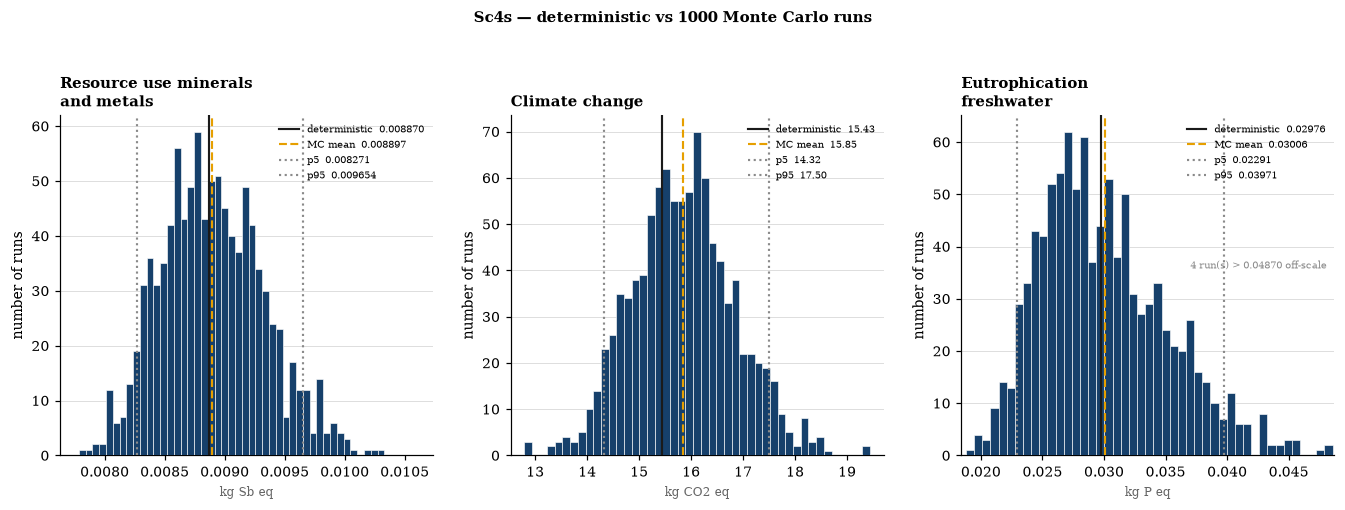

In [149]:
# --- Sc4s: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc4s" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc4s"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 4.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc4s"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc4s's net
        # is the "Sc4s" column (landfill earns no credit, so net == gross == Sc4s).
        det_val = ef.loc[cat, "sc4_saving"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc4"], edgecolor="white",
                linewidth=.4, zorder=4)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 4)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 4), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 4)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 4)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 4)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 4)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.4, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc4s — deterministic vs {len(runs['Sc4s'])} Monte Carlo runs",
                 x=0.5, y=1.04, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef41_mc_distribution_Sc4s_all")
    plt.show()
else:
    print("Sc4s export not available yet — skipping.")

#### Spread across every simulated system

saved: ef31_mc_boxplot_by_system_all.png / .pdf


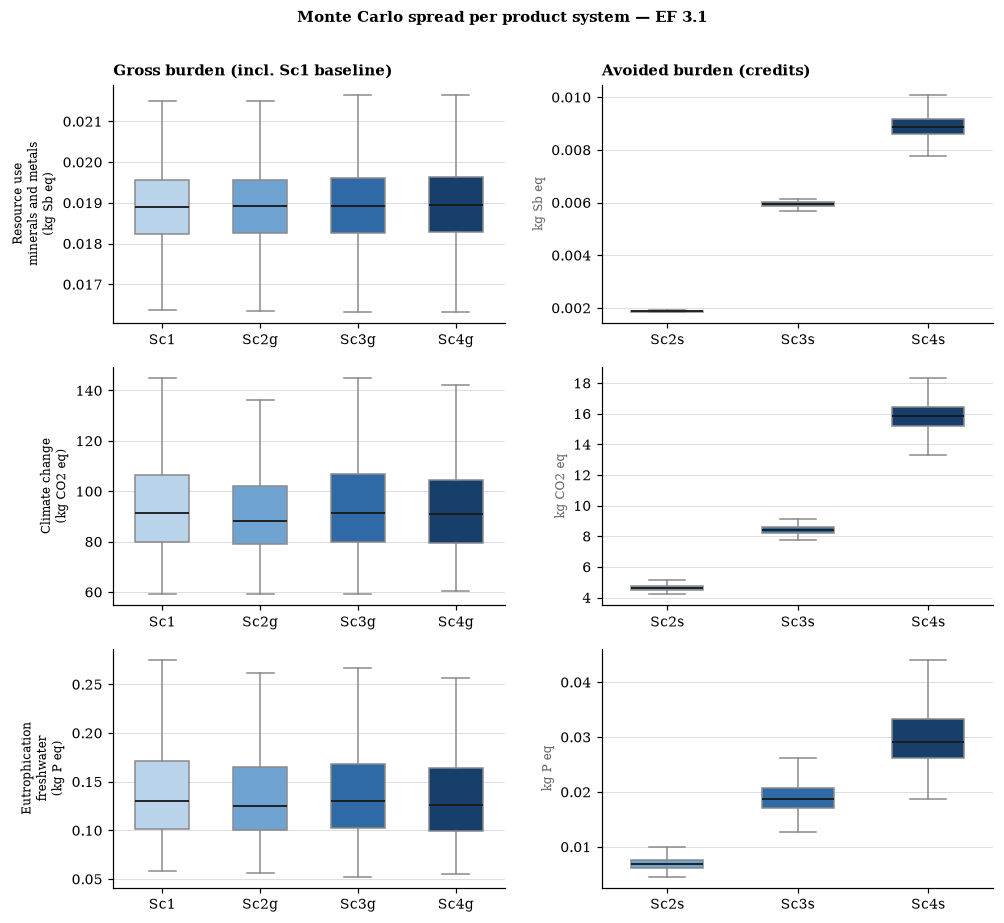

In [150]:
# --- Monte Carlo spread per product system, all reporting categories ---------
# Grid: one ROW per category, one COLUMN per system group (gross / credits).
# Each row has its own units, so every panel keeps its own y-scale.
if runs:
    gross_keys  = [k for k in SYSTEMS if k in runs and not k.endswith("s")]
    credit_keys = [k for k in SYSTEMS if k in runs and k.endswith("s")]

    cols = [(gross_keys, "Gross burden (incl. Sc1 baseline)"),
            (credit_keys, "Avoided burden (credits)")]
    cols = [c for c in cols if c[0]]
    cats = [c for c in REPORTING if any(c in runs[k] for k in runs)]

    # squeeze=False keeps axes 2-D even if a row or column drops out, so the
    # axes[i][j] indexing below never breaks.
    fig, axes = plt.subplots(len(cats), len(cols),
                             figsize=(4.6 * len(cols), 2.75 * len(cats)),
                             squeeze=False)

    for i, cat in enumerate(cats):
        for j, (keys, title) in enumerate(cols):
            ax = axes[i][j]
            ks = [k for k in keys if cat in runs[k]]

            # tick_labels=, not labels=: boxplot's `labels` was renamed in
            # matplotlib 3.9 and removed in 3.11 (this env runs 3.11.1).
            bp = ax.boxplot([runs[k][cat].values for k in ks], tick_labels=ks,
                            patch_artist=True, widths=.55, showfliers=False,
                            medianprops=dict(color="#1a1a1a", lw=1.2),
                            whiskerprops=dict(color="#8a8a8a"),
                            capprops=dict(color="#8a8a8a"))
            for patch, k in zip(bp["boxes"], ks):
                patch.set_facecolor(SC_COLOR.get(k[:3].lower(), "#c9d6e2"))
                patch.set_edgecolor("#8a8a8a")

            if i == 0:                      # column header on the top row only
                ax.set_title(title, fontsize=9.5)
            if j == 0:                      # category name labels the row
                ax.set_ylabel(f"{wrap(cat, 20)}\n({UNIT[cat]})", fontsize=8)
            else:
                ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
            ax.grid(axis="x", visible=False)

    # NOTE: every panel has an independent y-scale. Ranking within a panel is
    # readable; box heights across panels or columns are not comparable.
    fig.suptitle("Monte Carlo spread per product system — EF 3.1",
                 x=0.5, y=1.01, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0, h_pad=1.4)

    save(fig, "ef31_mc_boxplot_by_system_all")
    plt.show()
else:
    print("No Monte Carlo exports found yet.")


# **ReCiPe 2016 Midpoint (H) cross-check**

Characterised level only. No ReCiPe normalisation, no ReCiPe weighting: the screening rule
that selected the three reporting categories is an EF 3.1 procedure and is not repeated here.

The comparison is built on **ratios taken against Sc2 inside each method**, so the two methods
stay comparable where the unit differs (kg Sb eq against kg Cu eq). No quantity on this page is
expressed against Sc1.

Run the cells in order. The last cell writes `recipe_cross_check.xlsx` next to the notebook.

In [169]:
# --- setup and pairing -------------------------------------------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# IA is the by-name resolver defined in the setup cell
assert find_data("impact_EF31.csv").is_file(), "impact_EF31.csv not found beside the notebook"

ef = pd.read_csv(find_data("impact_EF31.csv"));       ef["category"] = ef["category"].str.strip()
rc = pd.read_csv(find_data("impact_ReCiPe_mid.csv")); rc["category"] = rc["category"].str.strip()
ef["unit"] = ef["unit"].str.strip();             rc["unit"] = rc["unit"].str.strip()

# EF key, name as printed in the thesis, ReCiPe counterpart
PAIRS = [("Resource use minerals and metals", "Resource use, minerals and metals", "Mineral resource scarcity"),
         ("Climate change",                   "Climate change",                   "Global warming"),
         ("Eutrophication freshwater",        "Eutrophication, freshwater",       "Freshwater eutrophication")]

def row(df, cat):
    r = df.loc[df["category"] == cat]
    assert len(r) == 1, f"category not matched uniquely: {cat}"
    return r.iloc[0]
print('loaded:', len(ef), 'EF rows,', len(rc), 'ReCiPe categories')

loaded: 25 EF rows, 18 ReCiPe categories


## First result — the full category pairing

EF 3.1 and ReCiPe 2016 do not name the same categories and do not measure them in the same units. The pairing below is what makes any comparison possible, and printing it is what lets a reader check it.

In [170]:
#--- the full category pairing, EF 3.1 against ReCiPe 2016 Midpoint (H) ------
ALL_PAIRS = [("Acidification",                                 "Terrestrial acidification"),
             ("Climate change",                                "Global warming"),
             ("Ecotoxicity freshwater",                        "Freshwater ecotoxicity"),
             ("Eutrophication freshwater",                     "Freshwater eutrophication"),
             ("Eutrophication marine",                         "Marine eutrophication"),
             ("Eutrophication terrestrial",                    None),
             ("Human toxicity cancer",                         "Human carcinogenic toxicity"),
             ("Human toxicity non-cancer",                     "Human non-carcinogenic toxicity"),
             ("Ionising radiation (human health)",             "Ionizing radiation"),
             ("Land use",                                      "Land use"),
             ("Ozone depletion",                               "Stratospheric ozone depletion"),
             ("Particulate matter",                            "Fine particulate matter formation"),
             ("Photochemical ozone formation (human health)",  "Ozone formation, Human health"),
             ("Resource use fossils",                          "Fossil resource scarcity"),
             ("Resource use minerals and metals",              "Mineral resource scarcity"),
             ("Water use",                                     "Water consumption")]

REPORTED = [k for k, _, _ in PAIRS]          # the three categories section 4.1 reports
efu, rcu = ef.set_index("category")["unit"], rc.set_index("category")["unit"]

rows = []
for a, b in ALL_PAIRS:
    ue = str(efu[a]).strip()
    ur = str(rcu[b]).strip() if b else ""
    rows.append({"EF 3.1 category": a, "EF unit": ue,
                 "ReCiPe counterpart": b if b else "no counterpart",
                 "ReCiPe unit": ur,
                 "same unit": ("yes" if ue == ur else "no") if b else "",
                 "reported in this study": "yes" if a in REPORTED else ""})
pairing = pd.DataFrame(rows)

n_pairs = sum(1 for _, b in ALL_PAIRS if b)
n_same  = int((pairing["same unit"] == "yes").sum())
unpaired_rc = sorted(set(rc["category"]) - {b for _, b in ALL_PAIRS if b})
unpaired_ef = [a for a, b in ALL_PAIRS if not b]

# the constraints the author stated for his own PAIRS list, checked, not assumed
assert n_pairs == 15,                 f"expected 15 pairs, built {n_pairs}"
assert n_same == 4,                   f"expected 4 shared units, found {n_same}"
assert unpaired_ef == ["Eutrophication terrestrial"], unpaired_ef
assert unpaired_rc == ["Marine ecotoxicity", "Ozone formation, Terrestrial ecosystems",
                       "Terrestrial ecotoxicity"], unpaired_rc
print(f"{n_pairs} pairs, {n_same} of them sharing a unit")
print("EF category with no counterpart:", unpaired_ef)
print("ReCiPe categories unpaired:", unpaired_rc)
pairing

15 pairs, 4 of them sharing a unit
EF category with no counterpart: ['Eutrophication terrestrial']
ReCiPe categories unpaired: ['Marine ecotoxicity', 'Ozone formation, Terrestrial ecosystems', 'Terrestrial ecotoxicity']


,EF 3.1 category,EF unit,ReCiPe counterpart,ReCiPe unit,same unit,reported in this study
0,Acidification,mol H+ eq,Terrestrial acidification,kg SO2 eq,no,
1,Climate change,kg CO2 eq,Global warming,kg CO2 eq,yes,yes
2,Ecotoxicity freshwater,CTUe,Freshwater ecotoxicity,"kg 1,4-DCB",no,
3,Eutrophication freshwater,kg P eq,Freshwater eutrophication,kg P eq,yes,yes
4,Eutrophication marine,kg N eq,Marine eutrophication,kg N eq,yes,
5,Eutrophication terrestrial,mol N eq,no counterpart,,,
6,Human toxicity cancer,CTUh,Human carcinogenic toxicity,"kg 1,4-DCB",no,
7,Human toxicity non-cancer,CTUh,Human non-carcinogenic toxicity,"kg 1,4-DCB",no,
8,Ionising radiation (human health),kBq U235 eq,Ionizing radiation,kBq Co-60 eq,no,
9,Land use,dimensionless (pt),Land use,m2a crop eq,no,


In [171]:
# --- does sharing a unit predict agreement? checked across all fifteen pairs --
chk = []
for a, b in ALL_PAIRS:
    if not b:
        continue
    e = ef.loc[ef["category"] == a].iloc[0]; r = rc.loc[rc["category"] == b].iloc[0]
    e2, e4 = float(e["sc2_saving"]), float(e["sc4_saving"])
    r2, r4 = float(r["sc2_saving"]), float(r["sc4_saving"])
    chk.append({"EF 3.1 category": a, "same unit": "yes" if str(e["unit"]).strip() == str(r["unit"]).strip() else "no",
                "EF Sc4 / Sc2": e4 / e2, "ReCiPe Sc4 / Sc2": r4 / r2,
                "absolute difference": abs(r4 / r2 - e4 / e2),
                "reported": "yes" if a in REPORTED else ""})
unit_check = pd.DataFrame(chk).sort_values("absolute difference", ascending=False)
print(unit_check.to_string(index=False, formatters={c: "{:.3f}".format for c in
      ["EF Sc4 / Sc2", "ReCiPe Sc4 / Sc2", "absolute difference"]}))
print()
print("Sharing a unit does NOT predict agreement across all fifteen pairs.")
print("  water use and water consumption differ in unit and agree to 0.000")
print("  ozone depletion shares its unit and differs by 0.241")
print("Within the three reported categories the two do coincide.")

                             EF 3.1 category same unit EF Sc4 / Sc2 ReCiPe Sc4 / Sc2 absolute difference reported
                   Human toxicity non-cancer        no        2.677            4.231               1.554         
            Resource use minerals and metals        no        4.739            3.494               1.245      yes
                      Ecotoxicity freshwater        no        4.875            4.236               0.639         
                          Particulate matter        no        2.785            3.167               0.382         
                             Ozone depletion       yes        3.750            3.991               0.241         
Photochemical ozone formation (human health)        no        3.567            3.805               0.238         
                       Eutrophication marine       yes        3.777            3.949               0.172         
                       Human toxicity cancer        no        1.951            1.812    

## First result — where the EF categories sit in ReCiPe's own ranking

ReCiPe 2016 Midpoint carries **normalisation factors but no midpoint weights**, so this
ranking is normalised only. The EF 3.1 ranking in the screening block is normalised **and**
weighted. The two are therefore not the same operation and must not be presented as
equivalent rankings.

What this ranking demonstrates is the size of the normalisation reference, not the size of
the burden. Mineral resource scarcity is normalised against 1.2 x 10^5 kg Cu eq while the
ecotoxicity categories are normalised against references of order 10^1, which is what places
it last. This is the reason ReCiPe normalisation is not used to select categories in this
study.

In [160]:
# --- ReCiPe midpoint ranking, normalised only --------------------------------
scr = pd.read_csv(IA / "impact_screening_ReCiPe_mid.csv")
scr["category"] = scr["category"].str.strip()
scr = scr.sort_values("share_pct", ascending=False).reset_index(drop=True)

# the normalisation reference behind each share, derived: raw Sc1 / normalised person-equivalents
raw = rc.set_index("category")["sc1"].astype(float)
scr["Sc1 characterised"] = scr["category"].map(raw)
scr["normalisation reference"] = scr["Sc1 characterised"] / scr["weighted_pe"].astype(float)
scr["unit"] = scr["category"].map(rc.set_index("category")["unit"])

RC_SET = scr.loc[scr["in_reporting_set"].astype(bool), "category"].tolist()
EF_COUNTERPARTS = [rcn for _, _, rcn in PAIRS]

print("ReCiPe reporting set, smallest set reaching 80 percent cumulative:")
for c in RC_SET:
    r = scr.loc[scr["category"] == c].iloc[0]
    print(f"   {c:34s} {r['share_pct']:7.4f} %   cumulative {r['cum_pct']:7.4f} %")
print()
print("Where the three EF 3.1 reporting categories sit in this ranking:")
for c in EF_COUNTERPARTS:
    r = scr.loc[scr["category"] == c].iloc[0]
    rank = int(scr.index[scr["category"] == c][0]) + 1
    print(f"   {c:34s} rank {rank:2d} of 18   {r['share_pct']:.4f} %   "
          f"normalisation reference {r['normalisation reference']:.4g} {r['unit']}")

overlap = sorted(set(RC_SET) & set(EF_COUNTERPARTS))
print()
print("Categories in both reporting sets:", overlap if overlap else "none")
assert scr["share_pct"].sum() > 99.99, "shares do not close on 100"

ReCiPe reporting set, smallest set reaching 80 percent cumulative:
   Freshwater ecotoxicity             37.7733 %   cumulative 37.7733 %
   Marine ecotoxicity                 29.0333 %   cumulative 66.8066 %
   Human carcinogenic toxicity        24.5192 %   cumulative 91.3259 %

Where the three EF 3.1 reporting categories sit in this ranking:
   Mineral resource scarcity          rank 18 of 18   0.0005 %   normalisation reference 1.201e+05 kg Cu eq
   Global warming                     rank 11 of 18   0.2522 %   normalisation reference 7990 kg CO2 eq
   Freshwater eutrophication          rank  4 of 18   4.8311 %   normalisation reference 0.6499 kg P eq

Categories in both reporting sets: none


saved: fig_recipe_midpoint_ranking.png / .pdf


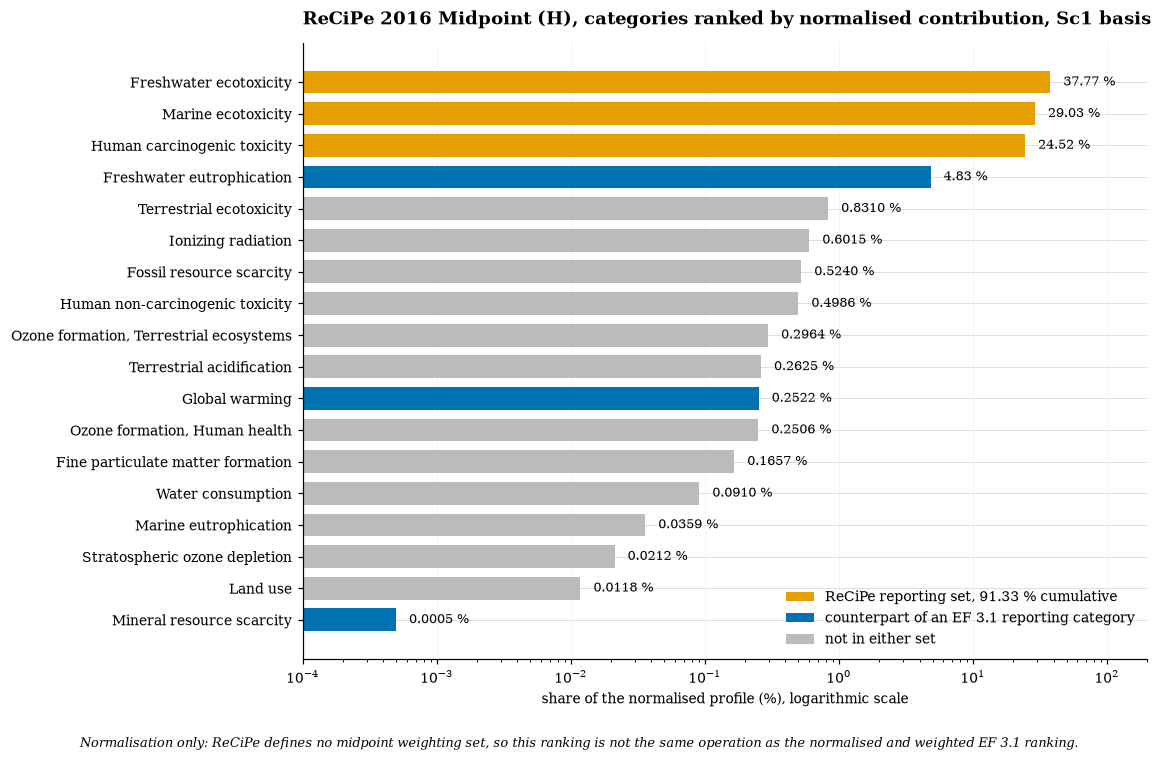

In [161]:
# --- figure, the ranking. Log axis: the shares span five orders of magnitude --
RC_C, EF_C, GREY = "#E69F00", "#0072B2", "#BBBBBB"

d = scr.iloc[::-1]                      # largest at the top of a horizontal bar chart
colors, edges = [], []
for c in d["category"]:
    if c in RC_SET:              colors.append(RC_C); edges.append("none")
    elif c in EF_COUNTERPARTS:   colors.append(EF_C); edges.append("none")
    else:                        colors.append(GREY); edges.append("none")

fig, ax = plt.subplots(figsize=(10.6, 6.6))
y = np.arange(len(d))
ax.barh(y, d["share_pct"].astype(float), color=colors, height=0.72)
ax.set_yticks(y); ax.set_yticklabels(d["category"], fontsize=9)
ax.set_xscale("log")
ax.set_xlim(1e-4, 200)
ax.set_xlabel("share of the normalised profile (%), logarithmic scale")
ax.grid(axis="x", lw=0.5, alpha=0.35); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

for yi, v in zip(y, d["share_pct"].astype(float)):
    ax.text(v * 1.25, yi, f"{v:.4f} %" if v < 1 else f"{v:.2f} %",
            va="center", fontsize=8.5)

ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, facecolor=RC_C),
                   plt.Rectangle((0, 0), 1, 1, facecolor=EF_C),
                   plt.Rectangle((0, 0), 1, 1, facecolor=GREY)],
          labels=["ReCiPe reporting set, 91.33 % cumulative",
                  "counterpart of an EF 3.1 reporting category",
                  "not in either set"],
          loc="lower right", frameon=False, fontsize=9)

ax.set_title("ReCiPe 2016 Midpoint (H), categories ranked by normalised contribution, Sc1 basis",
             fontsize=11.5, fontweight="bold", pad=12)
fig.text(0.5, -0.035,
         "Normalisation only: ReCiPe defines no midpoint weighting set, so this ranking is not the "
         "same operation as the normalised and weighted EF 3.1 ranking.",
         ha="center", fontsize=8.5, style="italic")
fig.tight_layout()

try:
    save(fig, "fig_recipe_midpoint_ranking")
except NameError:
    fig.savefig("fig_recipe_midpoint_ranking.png", dpi=300, bbox_inches="tight")
    fig.savefig("fig_recipe_midpoint_ranking.svg", bbox_inches="tight")
plt.show()

In [162]:
# --- the mechanism, in one small table ---------------------------------------
mech = scr.loc[scr["category"].isin(EF_COUNTERPARTS + RC_SET),
               ["category", "unit", "Sc1 characterised", "normalisation reference",
                "weighted_pe", "share_pct"]].copy()
mech["set"] = np.where(mech["category"].isin(RC_SET), "ReCiPe reporting set",
                       "EF 3.1 counterpart")
mech = mech.rename(columns={"weighted_pe": "normalised (person-equivalents)",
                            "share_pct": "share of profile (%)"})
print(mech.to_string(index=False, formatters={
    "Sc1 characterised": "{:.4g}".format,
    "normalisation reference": "{:.4g}".format,
    "normalised (person-equivalents)": "{:.4g}".format,
    "share of profile (%)": "{:.4f}".format}))
ranking_table = scr[["category", "unit", "Sc1 characterised", "normalisation reference",
                     "weighted_pe", "share_pct", "cum_pct", "in_reporting_set"]]

                   category       unit Sc1 characterised normalisation reference normalised (person-equivalents) share of profile (%)                  set
     Freshwater ecotoxicity kg 1,4-DCB             35.11                   25.17                           1.395              37.7733 ReCiPe reporting set
         Marine ecotoxicity kg 1,4-DCB             46.57                   43.44                           1.072              29.0333 ReCiPe reporting set
Human carcinogenic toxicity kg 1,4-DCB             9.323                    10.3                          0.9053              24.5192 ReCiPe reporting set
  Freshwater eutrophication    kg P eq            0.1159                  0.6499                          0.1784               4.8311   EF 3.1 counterpart
             Global warming  kg CO2 eq              74.4                    7990                        0.009311               0.2522   EF 3.1 counterpart
  Mineral resource scarcity   kg Cu eq             2.203              

## The pairing used for the comparison

Only two of the three pairs share a unit. The minerals pair does not, which is why the comparison that follows is built on ratios rather than on levels.

In [163]:
# --- the pairing, and its limit ----------------------------------------------
pairing = pd.DataFrame(
    [{"EF 3.1 category": nice, "EF unit": row(ef, k)["unit"],
      "ReCiPe counterpart": rcn, "ReCiPe unit": row(rc, rcn)["unit"],
      "shared unit": "yes" if row(ef, k)["unit"] == row(rc, rcn)["unit"] else "no"}
     for k, nice, rcn in PAIRS])
pairing

,EF 3.1 category,EF unit,ReCiPe counterpart,ReCiPe unit,shared unit
0,"Resource use, minerals and metals",kg Sb eq,Mineral resource scarcity,kg Cu eq,no
1,Climate change,kg CO2 eq,Global warming,kg CO2 eq,yes
2,"Eutrophication, freshwater",kg P eq,Freshwater eutrophication,kg P eq,yes


In [164]:
# --- TEST A, ordering. Ordinal, no reference scenario, no percentages --------
def monotonic(df, label):
    s2, s3, s4 = df["sc2_saving"].astype(float), df["sc3_saving"].astype(float), df["sc4_saving"].astype(float)
    ok = ((s2 < s3) & (s3 < s4))
    broken = df.loc[~ok, "category"].tolist()
    print(f"{label}: avoided impact increases Sc2 < Sc3 < Sc4 in {ok.sum()} of {len(df)} rows")
    if broken:
        print("   rows where it does not:", broken)
    return int(ok.sum()), len(df)

ef_ok, ef_n = monotonic(ef, "EF 3.1   (16 categories, 25 result rows)")
rc_ok, rc_n = monotonic(rc, "ReCiPe   (18 categories)")
assert ef_ok == ef_n and rc_ok == rc_n, "ordering claim would be false as written"

EF 3.1   (16 categories, 25 result rows): avoided impact increases Sc2 < Sc3 < Sc4 in 25 of 25 rows
ReCiPe   (18 categories): avoided impact increases Sc2 < Sc3 < Sc4 in 18 of 18 rows


In [165]:
# --- TEST B, ratios against Sc2. Dimensionless, comparable across methods ----
recs = []
for k, nice, rcn in PAIRS:
    for tag, r in (("EF 3.1", row(ef, k)), ("ReCiPe", row(rc, rcn))):
        s2, s3, s4 = float(r["sc2_saving"]), float(r["sc3_saving"]), float(r["sc4_saving"])
        recs.append({"Category pair": nice, "Counterpart": rcn, "Method": tag, "Unit": r["unit"],
                     "Sc3 / Sc2": s3 / s2, "Sc4 / Sc2": s4 / s2,
                     "Sc2 < Sc3 < Sc4": "yes" if s2 < s3 < s4 else "no"})
ratios = pd.DataFrame(recs)

# divergence between the two methods, in ratio points
div = (ratios.pivot_table(index="Category pair", columns="Method", values=["Sc3 / Sc2", "Sc4 / Sc2"])
       .assign(**{}))
delta = pd.DataFrame({
    "Sc3 / Sc2, ReCiPe minus EF": div[("Sc3 / Sc2", "ReCiPe")] - div[("Sc3 / Sc2", "EF 3.1")],
    "Sc4 / Sc2, ReCiPe minus EF": div[("Sc4 / Sc2", "ReCiPe")] - div[("Sc4 / Sc2", "EF 3.1")]})

print(ratios.to_string(index=False, formatters={"Sc3 / Sc2": "{:.3f}".format,
                                                "Sc4 / Sc2": "{:.3f}".format}))
print()
print(delta.to_string(formatters={c: "{:+.3f}".format for c in delta.columns}))

                    Category pair               Counterpart Method      Unit Sc3 / Sc2 Sc4 / Sc2 Sc2 < Sc3 < Sc4
Resource use, minerals and metals Mineral resource scarcity EF 3.1  kg Sb eq     3.219     4.739             yes
Resource use, minerals and metals Mineral resource scarcity ReCiPe  kg Cu eq     2.467     3.494             yes
                   Climate change            Global warming EF 3.1 kg CO2 eq     1.847     3.492             yes
                   Climate change            Global warming ReCiPe kg CO2 eq     1.850     3.503             yes
       Eutrophication, freshwater Freshwater eutrophication EF 3.1   kg P eq     2.775     4.314             yes
       Eutrophication, freshwater Freshwater eutrophication ReCiPe   kg P eq     2.775     4.314             yes

                                  Sc3 / Sc2, ReCiPe minus EF Sc4 / Sc2, ReCiPe minus EF
Category pair                                                                          
Climate change                  

In [166]:
# --- the independence check. Agreement is only evidence where the factors differ
lev = []
for k, nice, rcn in PAIRS:
    e, r = row(ef, k), row(rc, rcn)
    same_unit = e["unit"] == r["unit"]
    e2, r2 = float(e["sc2_saving"]), float(r["sc2_saving"])
    lev.append({"Category pair": nice, "shared unit": "yes" if same_unit else "no",
                "EF 3.1 Sc2 avoided": e2, "ReCiPe Sc2 avoided": r2,
                "relative difference (%)": (100.0 * abs(r2 - e2) / e2) if same_unit else np.nan})
levels = pd.DataFrame(lev)
print(levels.to_string(index=False, na_rep="not comparable",
                       formatters={"EF 3.1 Sc2 avoided": "{:.6g}".format,
                                   "ReCiPe Sc2 avoided": "{:.6g}".format,
                                   "relative difference (%)": "{:.4f}".format}))
print()
print("Where the two methods return nearly the same level, agreement reflects a shared")
print("characterisation factor and is not independent corroboration.")

                    Category pair shared unit EF 3.1 Sc2 avoided ReCiPe Sc2 avoided relative difference (%)
Resource use, minerals and metals          no         0.00187177           0.245437          not comparable
                   Climate change         yes            4.41898            4.47268                  1.2152
       Eutrophication, freshwater         yes         0.00689894         0.00689905                  0.0016

Where the two methods return nearly the same level, agreement reflects a shared
characterisation factor and is not independent corroboration.


In [167]:
# --- optional, the gross finding under both methods --------------------------
def spread(r):
    v = np.array([float(r["sc1"]), float(r["sc2_gross"]), float(r["sc3_gross"]), float(r["sc4_gross"])])
    return 100.0 * (v.max() - v.min()) / v.min()

gross = pd.DataFrame([{"Category pair": nice,
                       "EF 3.1 gross spread (%)": spread(row(ef, k)),
                       "ReCiPe gross spread (%)": spread(row(rc, rcn))} for k, nice, rcn in PAIRS])
print(gross.to_string(index=False, formatters={c: "{:.4f}".format for c in gross.columns[1:]}))

allrc = rc.assign(spread=rc.apply(spread, axis=1)).sort_values("spread", ascending=False)
w = allrc.iloc[0]
print(f"\nLargest gross spread across the four scenarios in any ReCiPe category: "
      f"{w['spread']:.4f} % ({w['category']})")

                    Category pair EF 3.1 gross spread (%) ReCiPe gross spread (%)
Resource use, minerals and metals                  0.0028                  0.0066
                   Climate change                  0.0955                  0.0949
       Eutrophication, freshwater                  0.0153                  0.0153

Largest gross spread across the four scenarios in any ReCiPe category: 0.7473 % (Human non-carcinogenic toxicity)


saved: fig_recipe_ratio_cross_check.png / .pdf


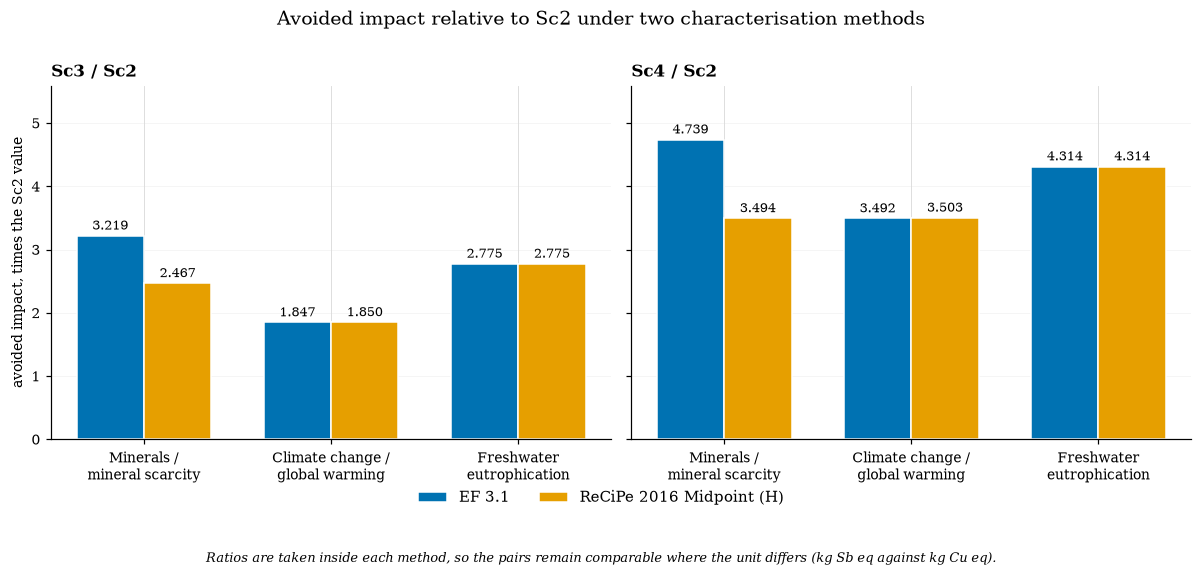

In [168]:
# --- figure, the six ratios. The only quantity comparable across the methods -
EF_C, RC_C = "#0072B2", "#E69F00"     # notebook palette, colour-vision-deficiency safe
labels = [nice for _, nice, _ in PAIRS]
short  = ["Minerals /\nmineral scarcity", "Climate change /\nglobal warming",
          "Freshwater\neutrophication"]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharey=True)
x = np.arange(len(PAIRS)); w = 0.36

for ax, col in zip(axes, ["Sc3 / Sc2", "Sc4 / Sc2"]):
    e = [ratios.loc[(ratios["Category pair"] == n) & (ratios["Method"] == "EF 3.1"), col].iloc[0] for n in labels]
    r = [ratios.loc[(ratios["Category pair"] == n) & (ratios["Method"] == "ReCiPe"), col].iloc[0] for n in labels]
    b1 = ax.bar(x - w/2, e, w, color=EF_C, label="EF 3.1", edgecolor="white")
    b2 = ax.bar(x + w/2, r, w, color=RC_C, label="ReCiPe 2016 Midpoint (H)", edgecolor="white")
    for bars in (b1, b2):
        ax.bar_label(bars, fmt="%.3f", fontsize=8.5, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(short, fontsize=9)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", lw=0.5, alpha=0.35); ax.set_axisbelow(True)

axes[0].set_ylabel("avoided impact, times the Sc2 value")
axes[0].set_ylim(0, max(ratios["Sc4 / Sc2"]) * 1.18)
handles, lab = axes[0].get_legend_handles_labels()
fig.legend(handles, lab, loc="lower center", ncol=2, frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Avoided impact relative to Sc2 under two characterisation methods",
             fontsize=12.5, y=1.01)
fig.text(0.5, -0.13, "Ratios are taken inside each method, so the pairs remain comparable where the "
                     "unit differs (kg Sb eq against kg Cu eq).",
         ha="center", fontsize=8.5, style="italic")
fig.tight_layout()

try:
    save(fig, "fig_recipe_ratio_cross_check")      # notebook helper, cell 3
except NameError:
    fig.savefig("fig_recipe_ratio_cross_check.png", dpi=300, bbox_inches="tight")
    fig.savefig("fig_recipe_ratio_cross_check.svg", bbox_inches="tight")
plt.show()

In [172]:
# --- export, so the tables reach Word without a decimal-separator conversion --
with pd.ExcelWriter("recipe_cross_check.xlsx") as xl:
    ranking_table.to_excel(xl, sheet_name="recipe_ranking", index=False)
    pairing.to_excel(xl, sheet_name="pairing",        index=False)
    ratios.to_excel(xl,  sheet_name="ratios_vs_Sc2",  index=False)
    levels.to_excel(xl,  sheet_name="independence",   index=False)
    gross.to_excel(xl,   sheet_name="gross_spread",   index=False)
    pd.DataFrame([{"check": "avoided increases Sc2 < Sc3 < Sc4",
                   "EF 3.1": f"{ef_ok} of {ef_n} rows",
                   "ReCiPe": f"{rc_ok} of {rc_n} categories"}]).to_excel(
                       xl, sheet_name="ordering", index=False)
print("written: recipe_cross_check.xlsx")

written: recipe_cross_check.xlsx
